In [1]:
!pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
print(torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

2.11.0+cu128
cuda


Let's download training and test datasets from AWS using `datasets.MNIST` class. Before we start the download we need to set up the transform callable to make sure data are transformed int PyTorch Tensors.

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

In [5]:
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

In [6]:
print(len(train_data), len(test_data))

60000 10000


We then randomly split training data into `train_data` and `valid_data` for finetuning purpose and leave the `test_data` to asses model performance on generalization.

In [7]:
train_data, valid_data = random_split(train_data, [50000, 10000])

In [8]:
print(len(train_data), len(valid_data))

50000 10000


In [9]:
train_dl = DataLoader(train_data, batch_size=128, shuffle=True)
valid_dl = DataLoader(valid_data, batch_size=128, shuffle=False)
test_dl = DataLoader(test_data, batch_size=128, shuffle=False)

In [10]:
print(len(train_dl), len(valid_dl), len(test_dl))

391 79 79


In [11]:
first_batch = next(iter(train_dl))
first_batch[0].shape

torch.Size([128, 1, 28, 28])

In [12]:
def display_images(input, output, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):

        # Visualize input
        ax = plt.subplot(2, n, i + 1)
        item = input[i].permute(1, 2, 0)
        plt.imshow(item.cpu().numpy(), cmap='grey')
        plt.title("Original")
        ax.axis('off')

        # Visualize output
        ax = plt.subplot(2, n, i + 1 + n)
        item = output[i].view(1, 28, 28).permute(1, 2, 0)
        plt.imshow(item.detach().cpu().numpy(), cmap='grey')
        plt.title("Reconstructed")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [107]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)

        return sample

    def forward(self, x):

        x = x.view(x.shape[0], -1)
        mu_logvar = self.encoder(x).view(x.shape[0], 2, latent_dim)

        mu = mu_logvar[:, 0, :]
        logvar = mu_logvar[0, 1, :]
        z = self.reparameterize(mu, logvar)

        x_hat = self.decoder(z).view(x.shape[0], 1, 28, 28)

        return x_hat, mu, logvar

In [108]:
input_dim = 1 * 28 * 28
hidden_dim = 256
latent_dim = 128

In [109]:
model = LinearVAE(input_dim, hidden_dim, latent_dim).to(device)

print(model)

LinearVAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


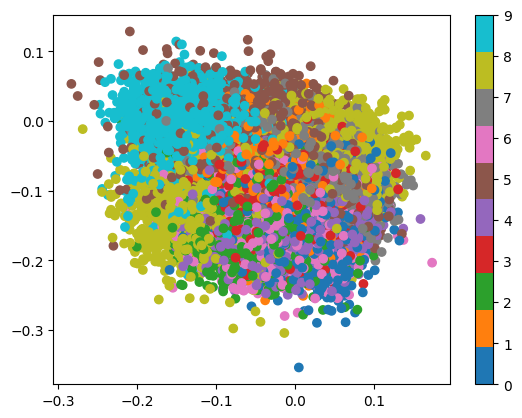

In [110]:
for X_train, y_train in train_dl:

    X_train = X_train.view(X_train.shape[0], -1).to(device)
    z = model.encoder(X_train)
    z = z.detach().cpu().numpy()

    plt.scatter(z[:, 0], z[:, 1], c=y_train, cmap="tab10")

plt.colorbar()
plt.show()

In [111]:
epochs = 30
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [114]:
from collections import defaultdict

def train(train_loader, valid_loader, model, optimizer , epochs, device):

    train_losses, val_losses = [], []
    latent_params = defaultdict(list)

    for epoch in tqdm(range(epochs + 1)):
        if epoch > 0:

            model.train()
            training_loss = 0

            for X, _ in train_loader:
                optimizer.zero_grad()

                X = X.to(device)
                X_hat, mu, logvar = model(X)

                # bce_loss = F.binary_cross_entropy(
                #     X_hat, X.view(X.shape[0], -1), reduction="sum")
                bce_loss = F.binary_cross_entropy(X_hat, X, reduction="sum")
                kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                loss = bce_loss + kld_loss
                loss.backward()
                training_loss += loss.item()

                optimizer.step()

            train_loss = training_loss / len(train_loader.dataset)
            train_losses.append(train_loss)
            print(f"Epoch: {epoch} | Training Loss: {train_loss:.5f}")

        means, logvars, labels = [], [], []
        with torch.no_grad():
            model.eval()
            validation_loss = 0
            for X_val, y_val in valid_loader:

                X_val = X_val.to(device)
                X_val_hat, mu_val, logvar_val = model(X_val)

                # bce_loss = F.binary_cross_entropy(
                #     X_val_hat, X_val.view(X_val.shape[0], -1), reduction="sum")
                bce_loss = F.binary_cross_entropy(
                    X_val_hat, X_val, reduction="sum")
                kld_loss = -0.5 * torch.sum(1 + logvar_val - mu_val.pow(2) - logvar_val.exp())
                loss_val = bce_loss + kld_loss

                validation_loss += loss_val.item()

                means.append(mu_val.detach().cpu().numpy())
                logvars.append(logvar_val.detach().cpu().numpy())
                labels.append(y_val.cpu().numpy())

            valid_loss = validation_loss / len(valid_loader.dataset)
            val_losses.append(valid_loss)

        latent_params["means"].append(np.concatenate(means, axis=0))
        latent_params["logvars"].append(np.concatenate(logvars, axis=0))
        latent_params["labels"].append(np.concatenate(labels, axis=0))

        print(f"Epoch: {epoch} | Validation Loss: {valid_loss:.5f}")
        display_images(X_val, X_val_hat)

    return train_losses, val_losses, latent_params

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch: 0 | Validation Loss: 548.77562


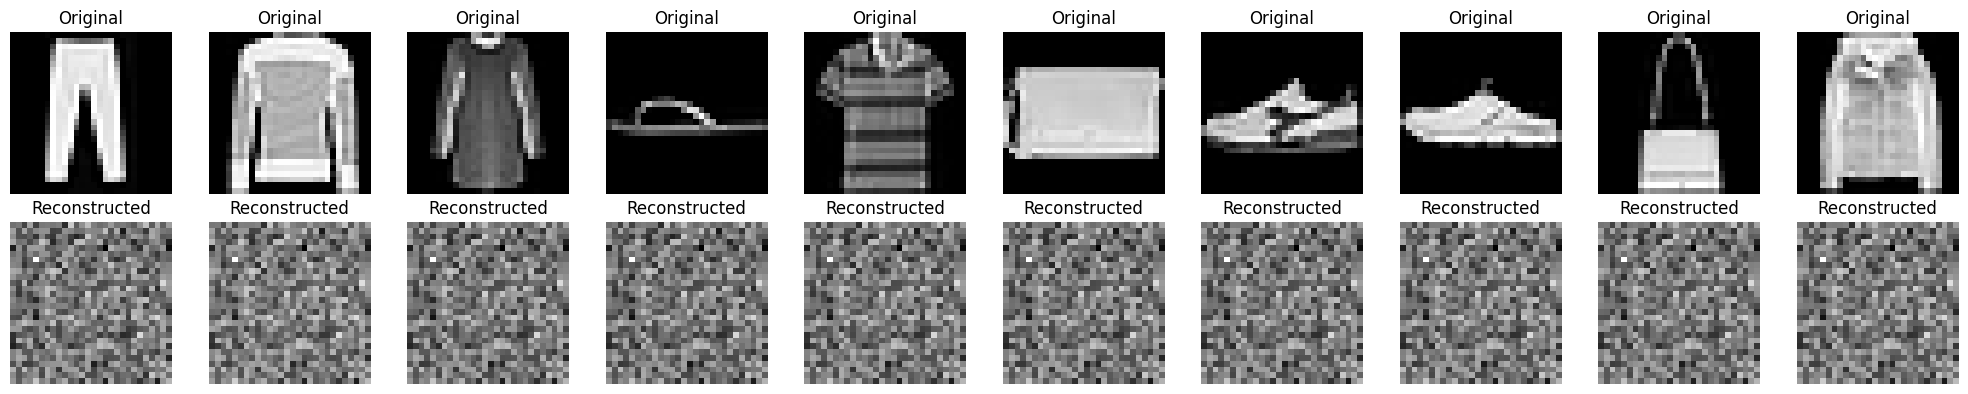

  3%|▎         | 1/31 [00:03<01:47,  3.58s/it]

Epoch: 1 | Training Loss: 333.64466
Epoch: 1 | Validation Loss: 299.18311


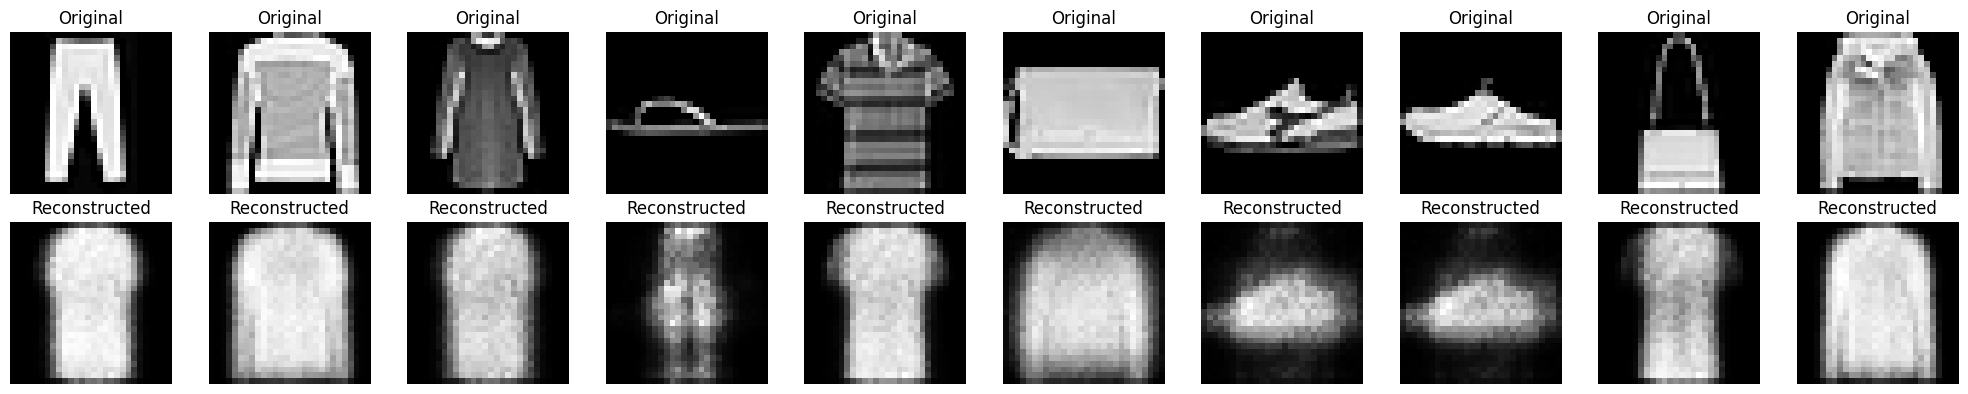

  6%|▋         | 2/31 [00:12<03:08,  6.51s/it]

Epoch: 2 | Training Loss: 294.20636
Epoch: 2 | Validation Loss: 288.62910


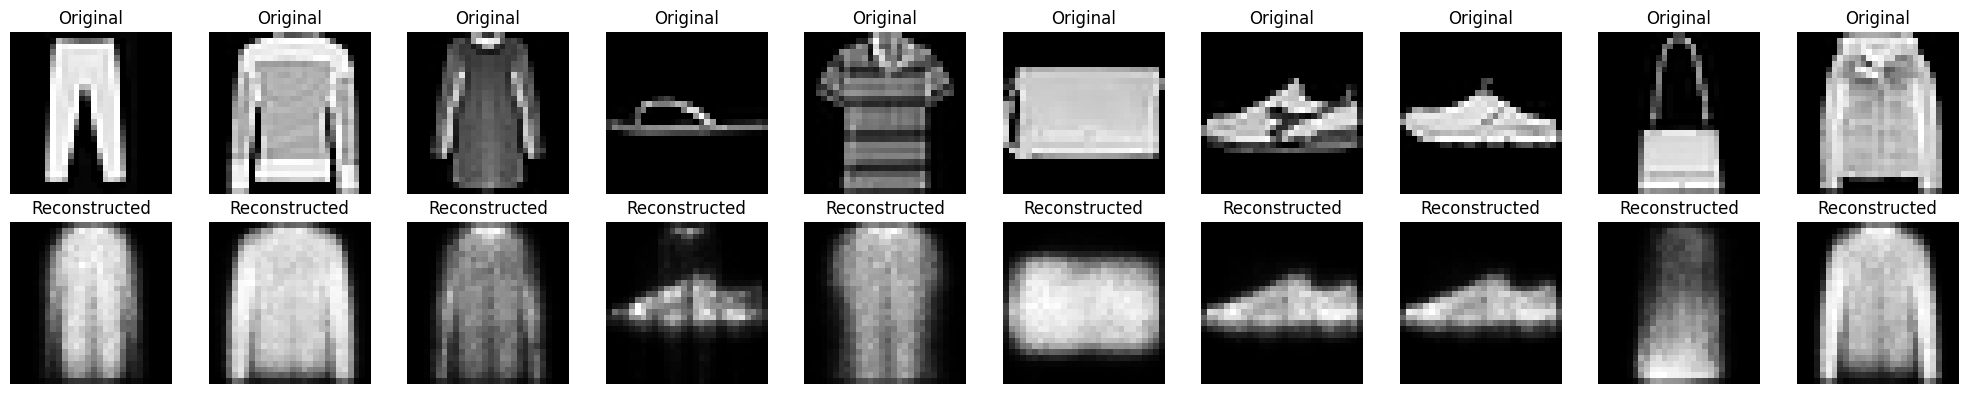

 10%|▉         | 3/31 [00:21<03:35,  7.69s/it]

Epoch: 3 | Training Loss: 287.19707
Epoch: 3 | Validation Loss: 284.60233


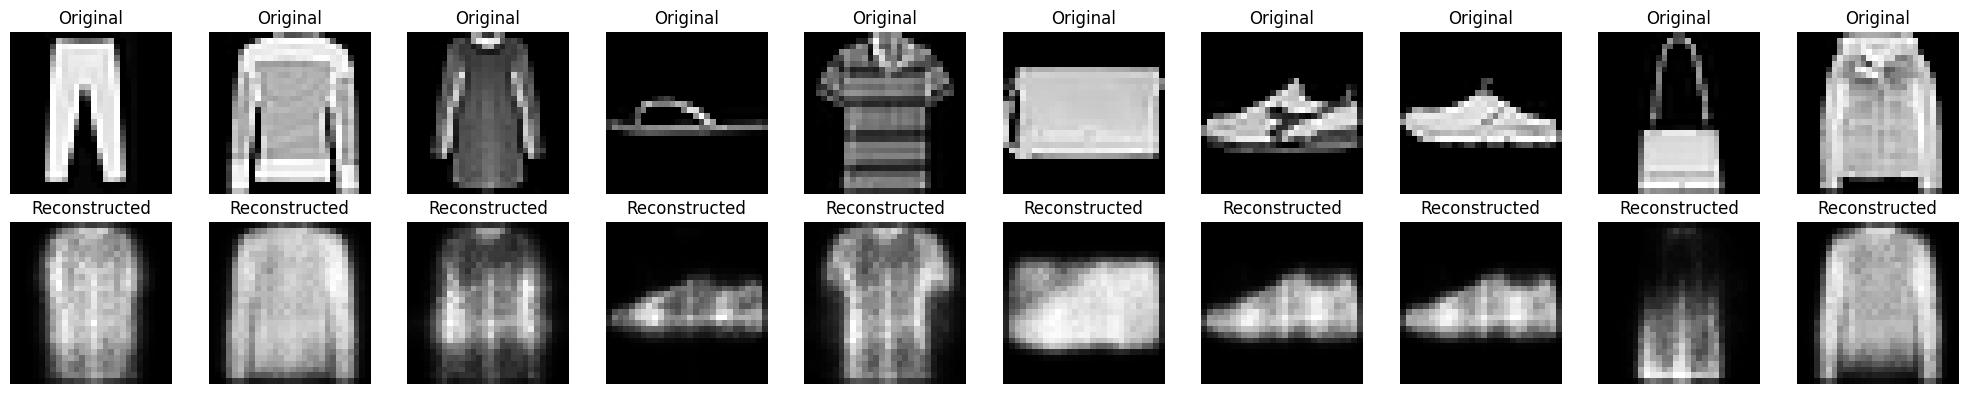

 13%|█▎        | 4/31 [00:29<03:29,  7.77s/it]

Epoch: 4 | Training Loss: 284.36492
Epoch: 4 | Validation Loss: 279.31792


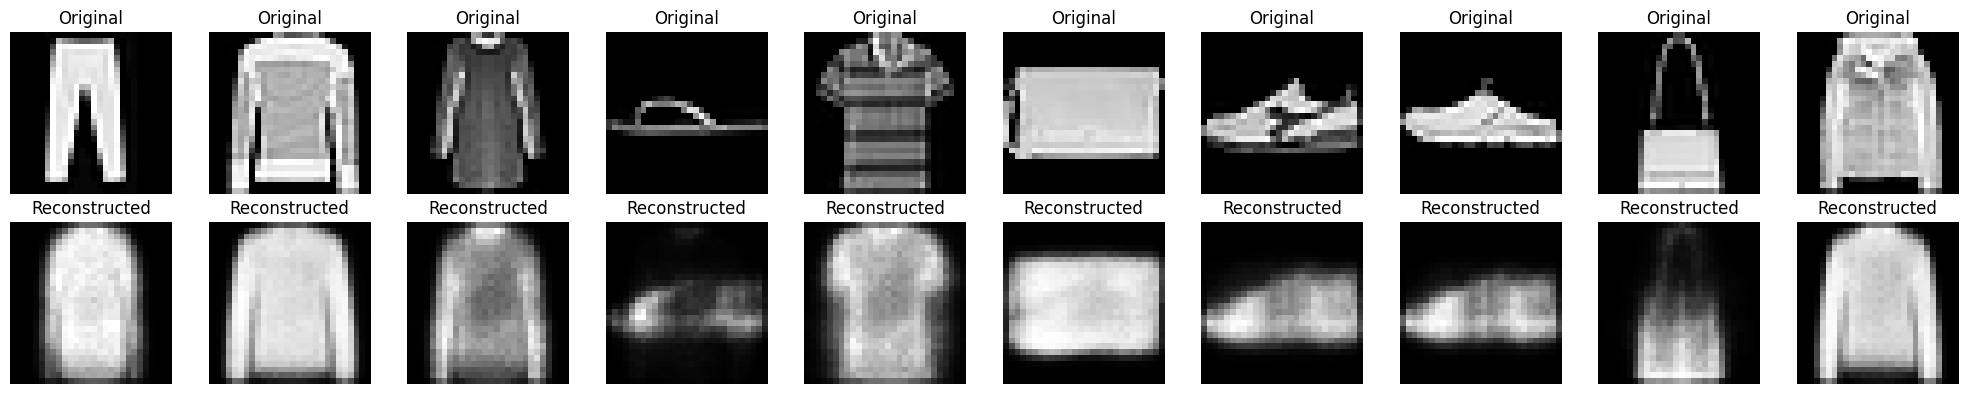

 16%|█▌        | 5/31 [00:37<03:31,  8.13s/it]

Epoch: 5 | Training Loss: 282.56909
Epoch: 5 | Validation Loss: 282.28393


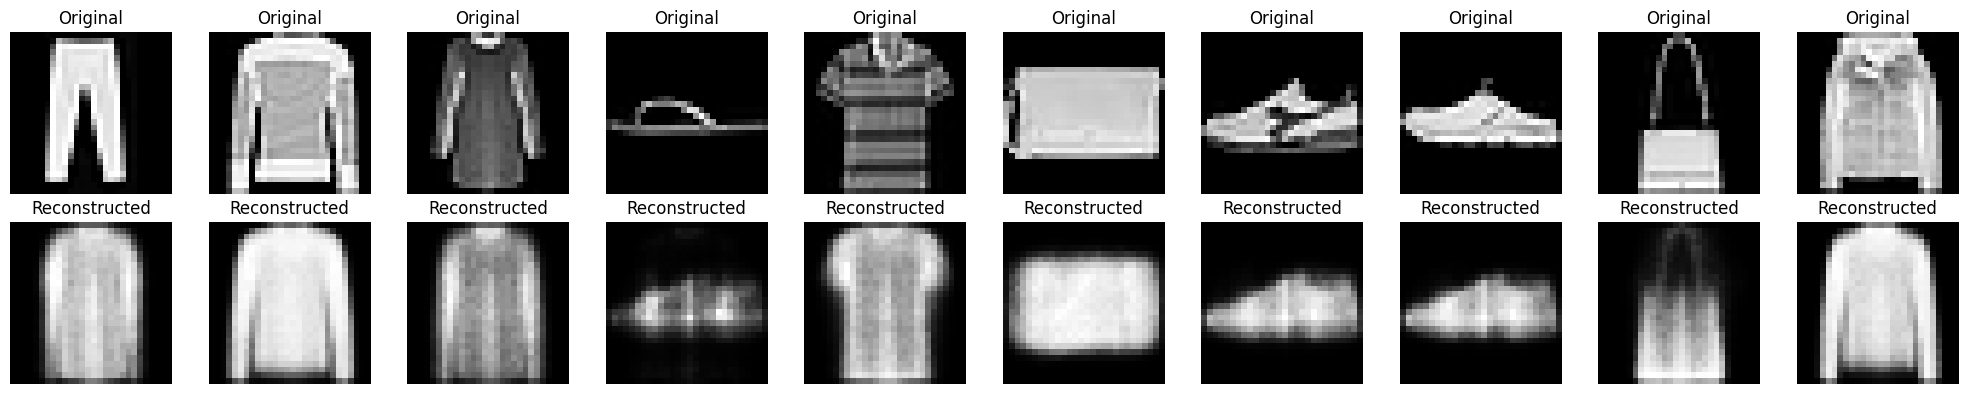

 19%|█▉        | 6/31 [00:46<03:26,  8.27s/it]

Epoch: 6 | Training Loss: 280.30419
Epoch: 6 | Validation Loss: 276.68705


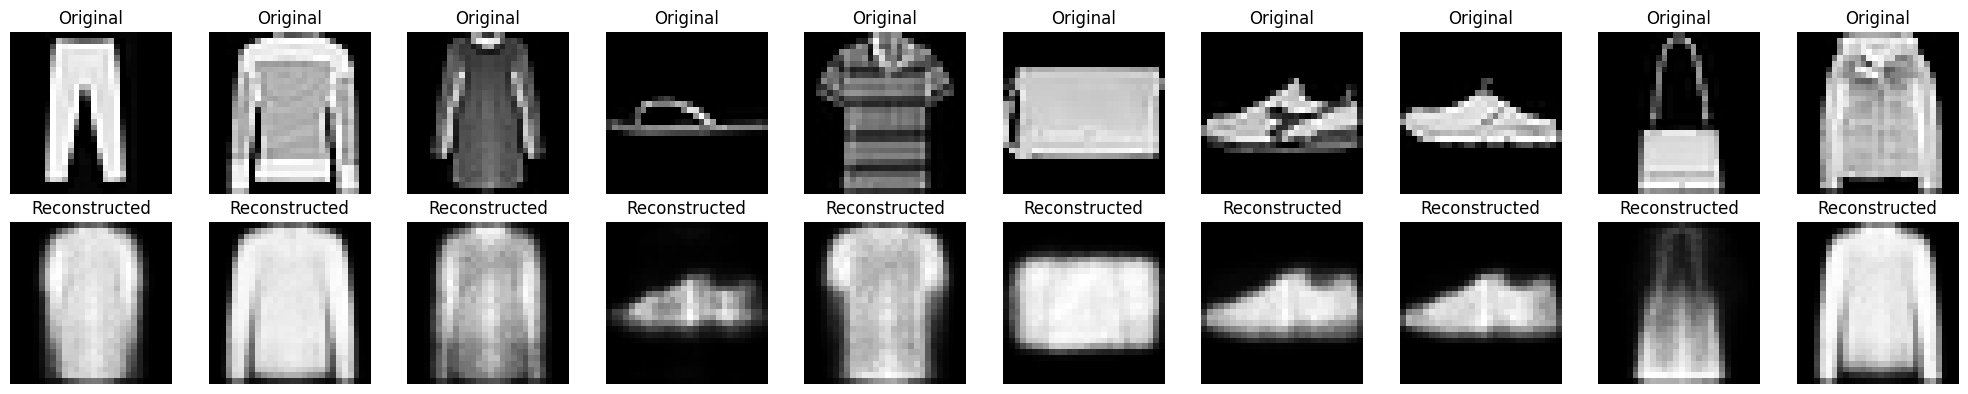

 23%|██▎       | 7/31 [00:54<03:14,  8.12s/it]

Epoch: 7 | Training Loss: 277.96572
Epoch: 7 | Validation Loss: 276.61313


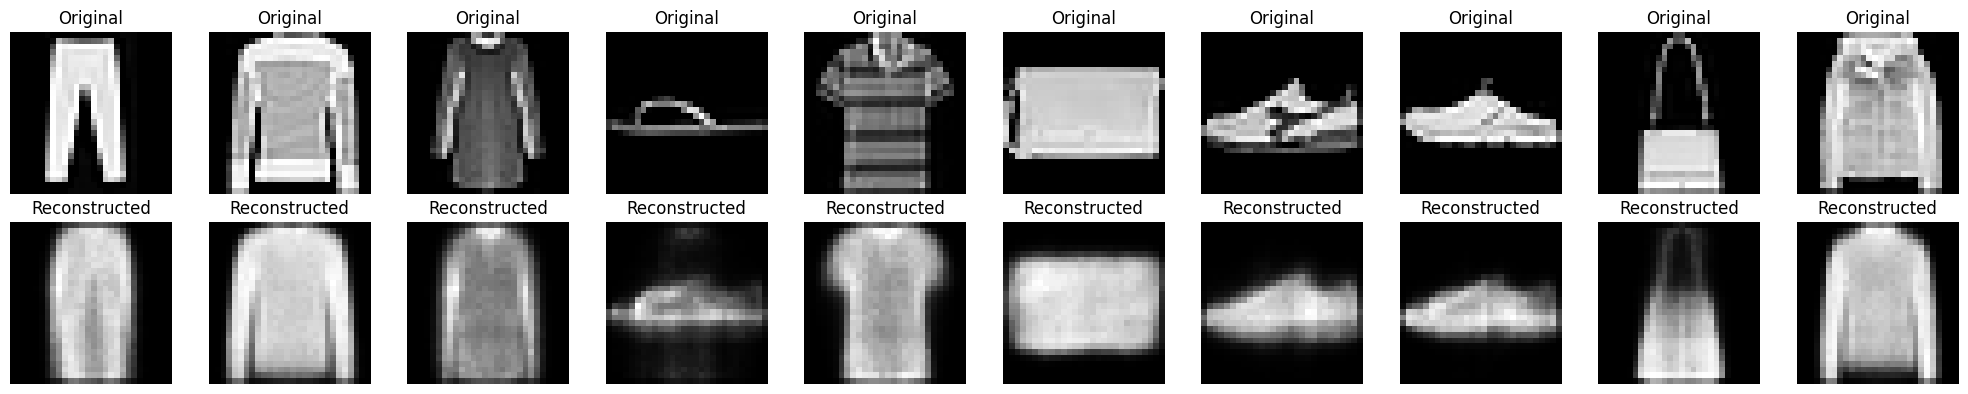

 26%|██▌       | 8/31 [01:02<03:10,  8.27s/it]

Epoch: 8 | Training Loss: 276.23332
Epoch: 8 | Validation Loss: 277.71043


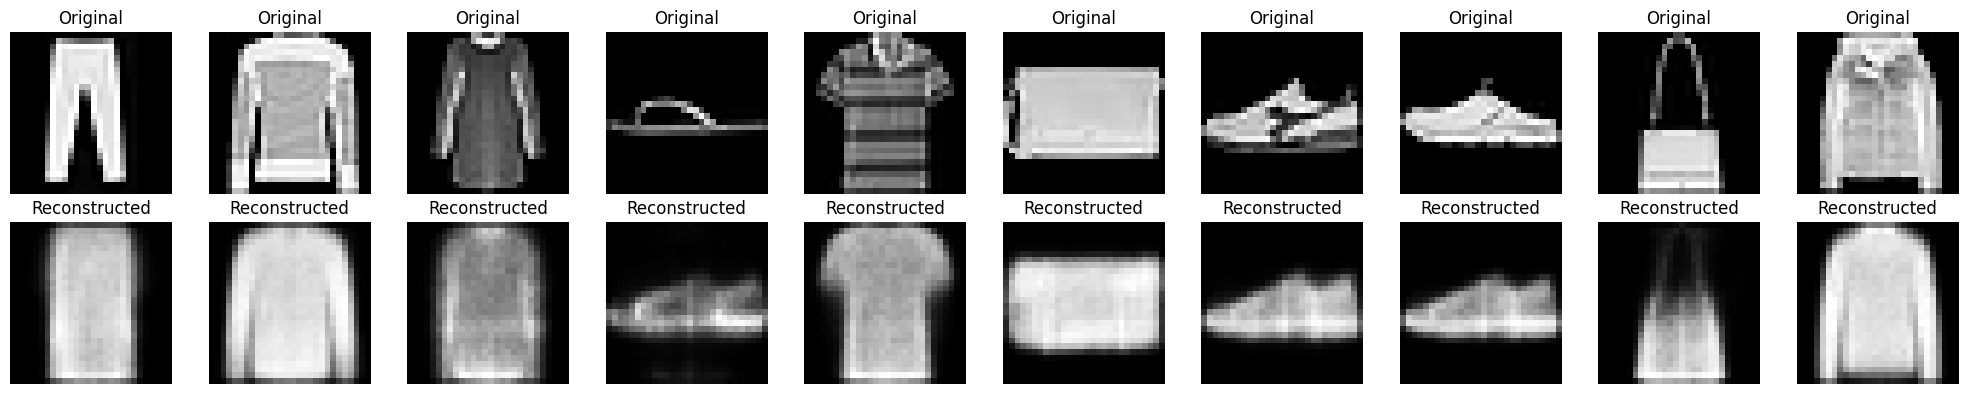

 29%|██▉       | 9/31 [01:11<03:06,  8.48s/it]

Epoch: 9 | Training Loss: 276.20643
Epoch: 9 | Validation Loss: 273.21832


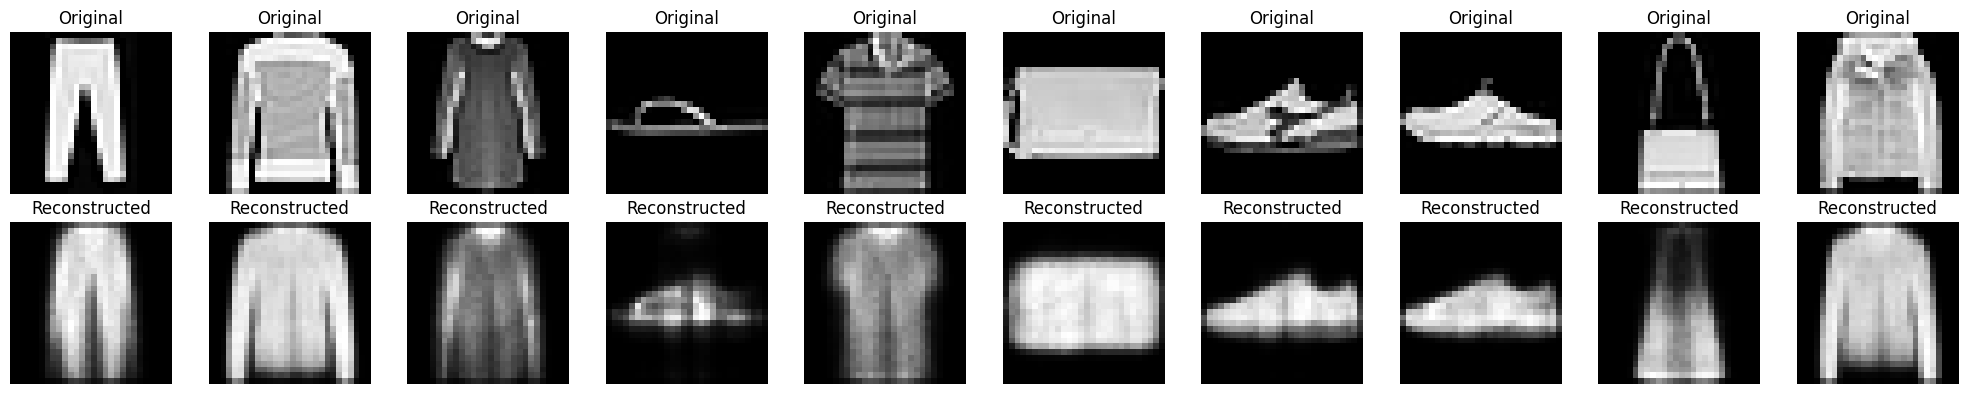

 32%|███▏      | 10/31 [01:19<02:55,  8.34s/it]

Epoch: 10 | Training Loss: 273.75121
Epoch: 10 | Validation Loss: 273.18428


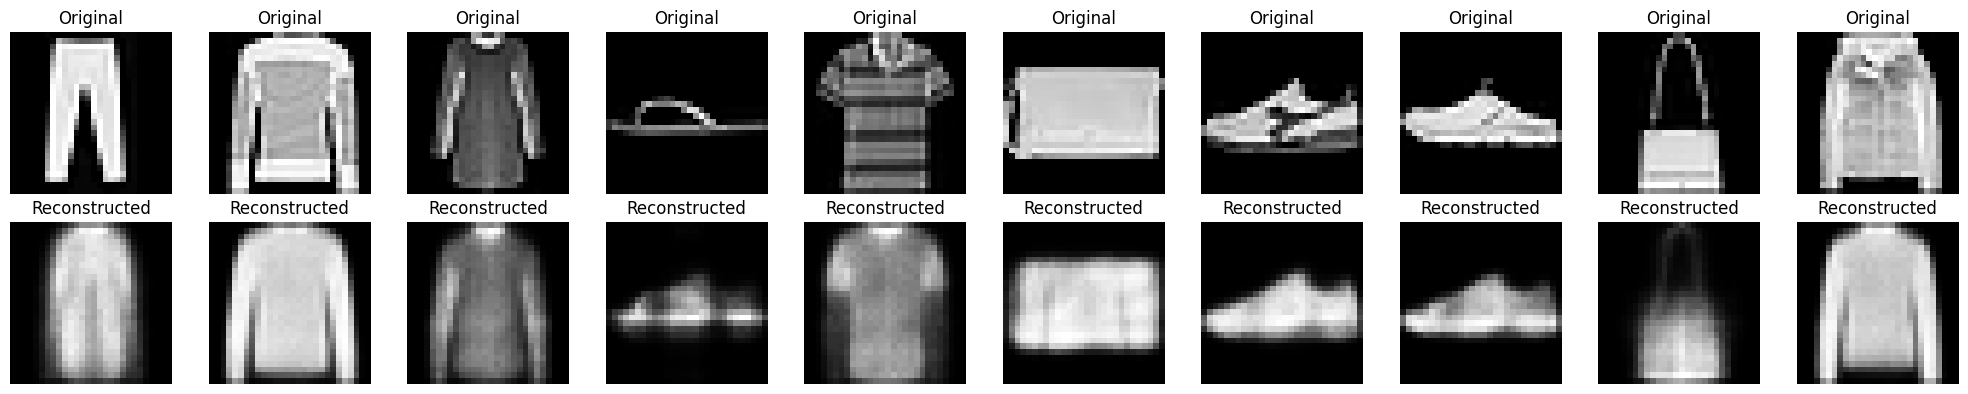

 35%|███▌      | 11/31 [01:28<02:47,  8.36s/it]

Epoch: 11 | Training Loss: 272.08331
Epoch: 11 | Validation Loss: 270.88642


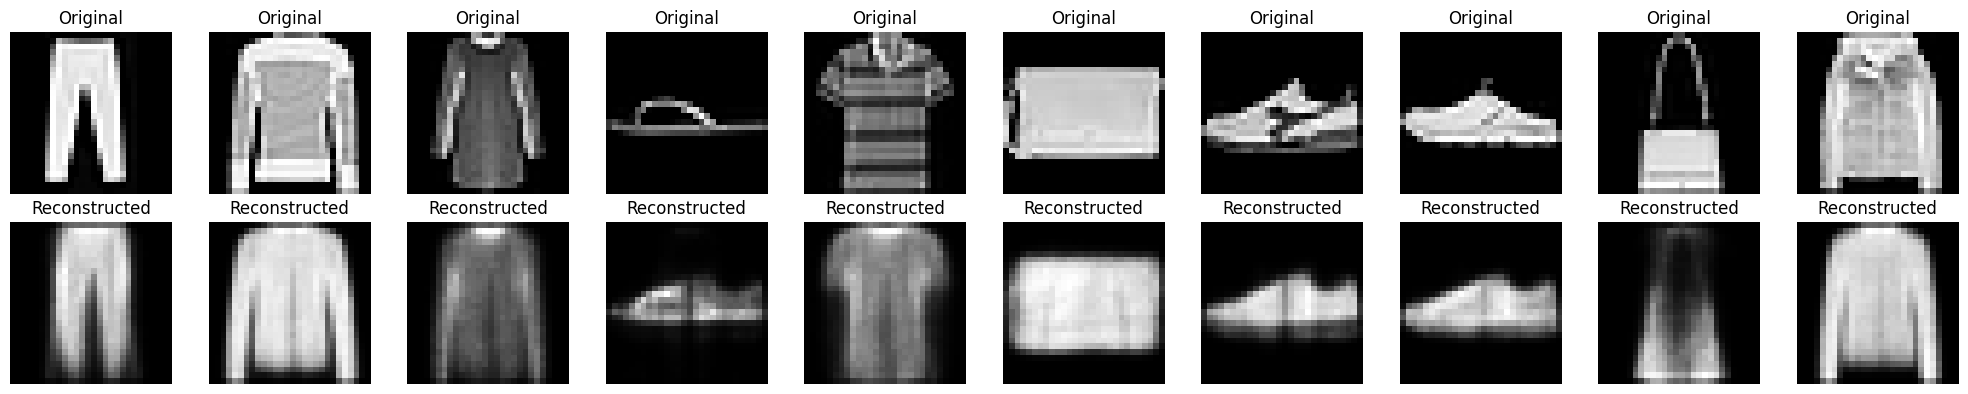

 39%|███▊      | 12/31 [01:36<02:40,  8.47s/it]

Epoch: 12 | Training Loss: 270.31484
Epoch: 12 | Validation Loss: 268.91218


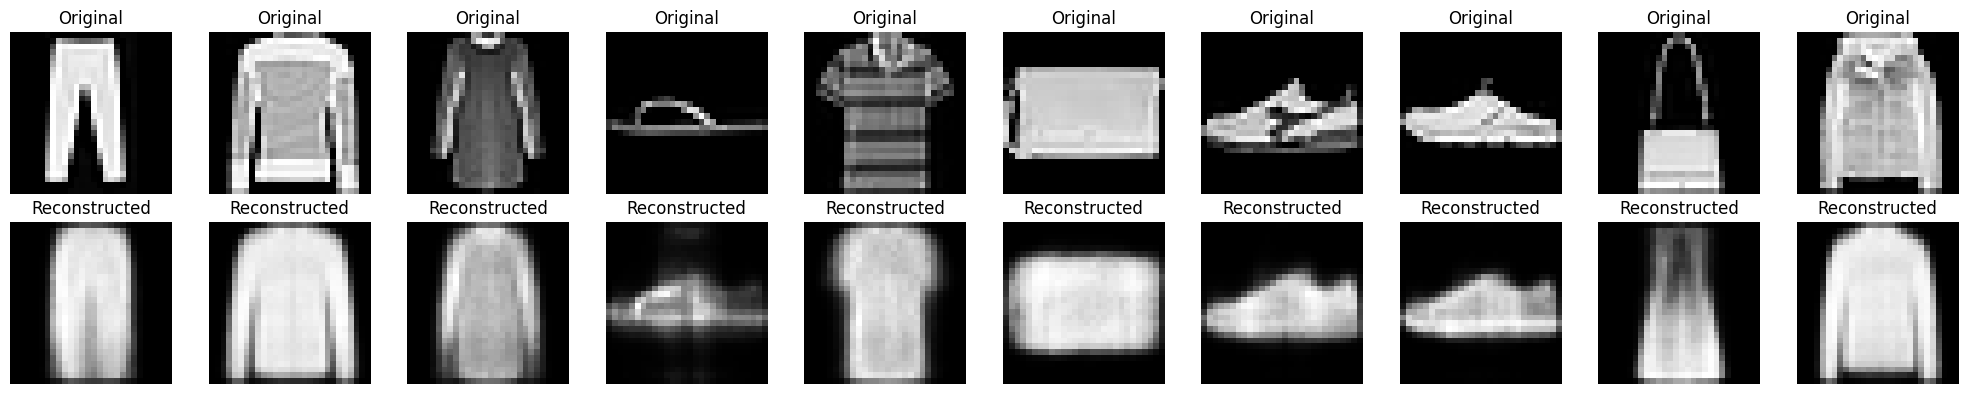

 42%|████▏     | 13/31 [01:45<02:31,  8.40s/it]

Epoch: 13 | Training Loss: 268.76231
Epoch: 13 | Validation Loss: 265.97378


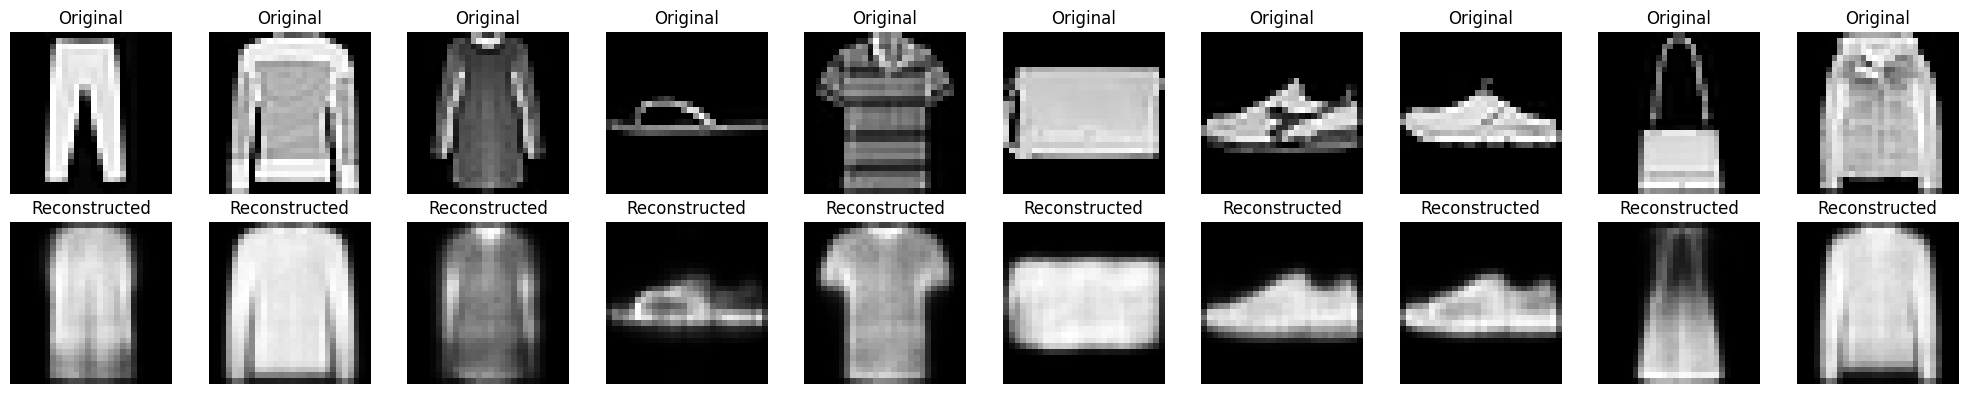

 45%|████▌     | 14/31 [01:53<02:24,  8.52s/it]

Epoch: 14 | Training Loss: 266.44235
Epoch: 14 | Validation Loss: 264.08022


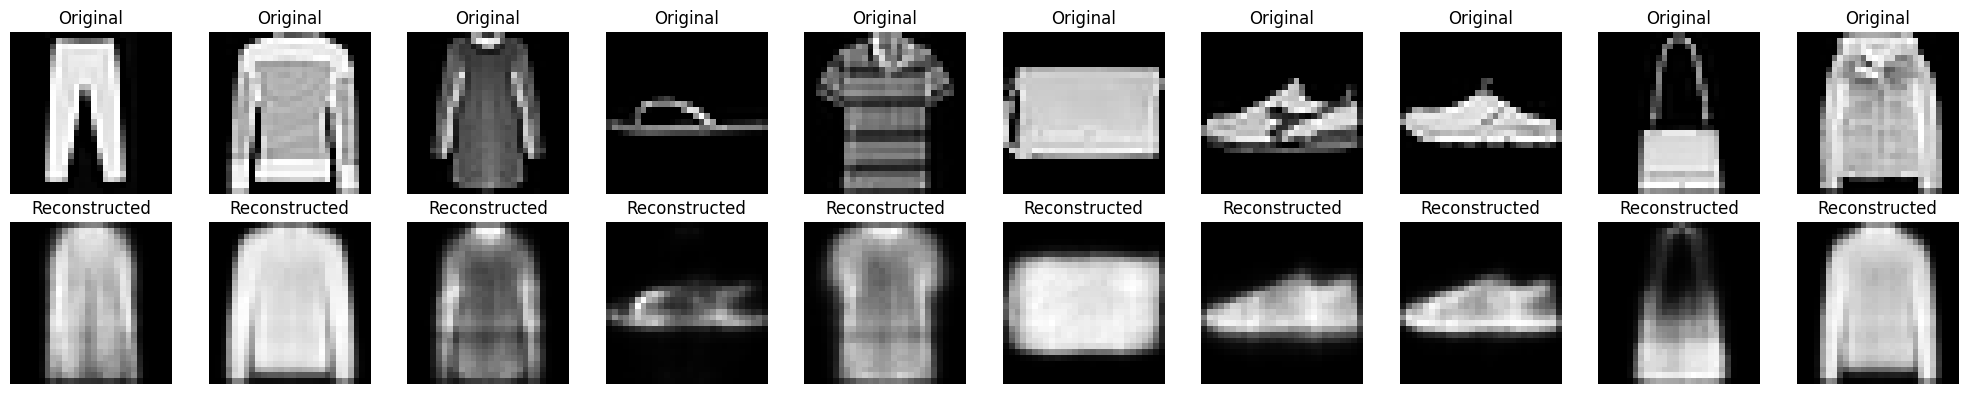

 48%|████▊     | 15/31 [02:02<02:17,  8.58s/it]

Epoch: 15 | Training Loss: 265.43092
Epoch: 15 | Validation Loss: 263.71308


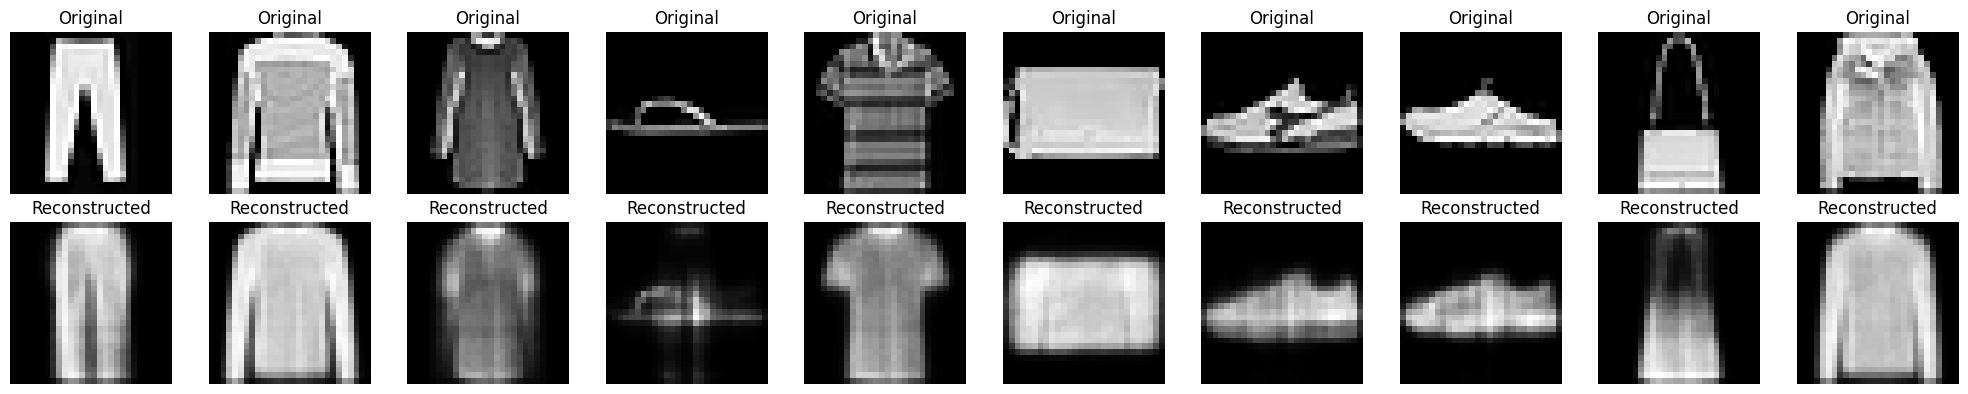

 52%|█████▏    | 16/31 [02:11<02:07,  8.51s/it]

Epoch: 16 | Training Loss: 263.37935
Epoch: 16 | Validation Loss: 263.28644


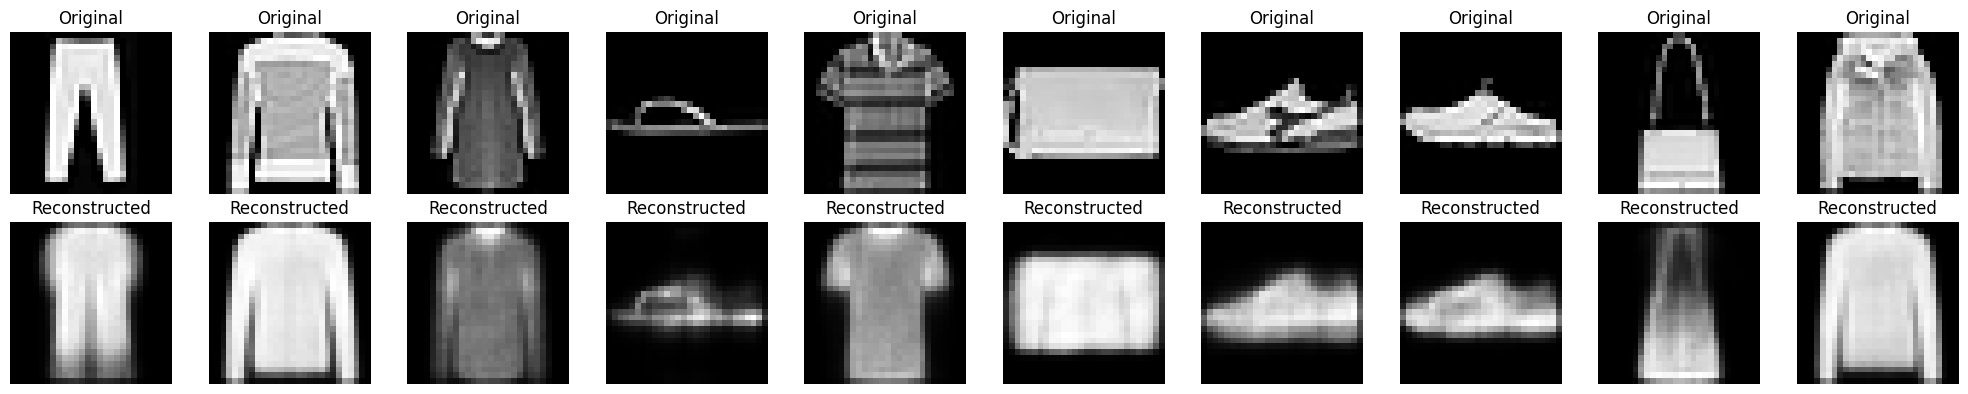

 55%|█████▍    | 17/31 [02:19<01:58,  8.43s/it]

Epoch: 17 | Training Loss: 261.46560
Epoch: 17 | Validation Loss: 259.71381


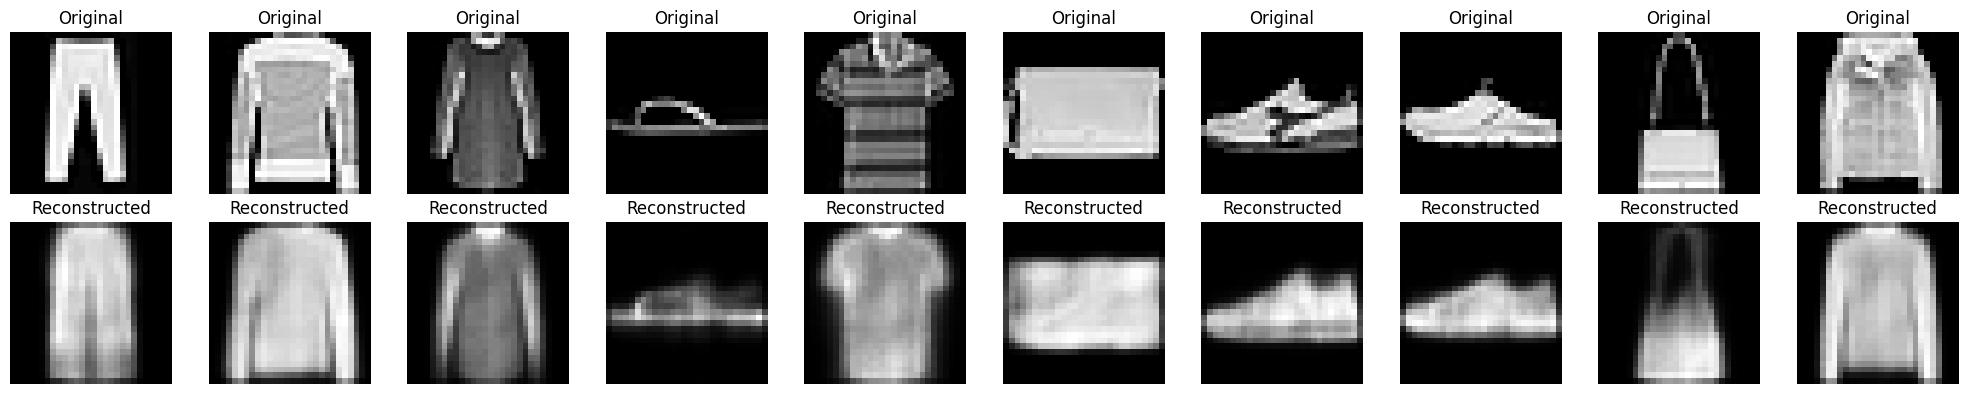

 58%|█████▊    | 18/31 [02:27<01:50,  8.50s/it]

Epoch: 18 | Training Loss: 260.42381
Epoch: 18 | Validation Loss: 258.79075


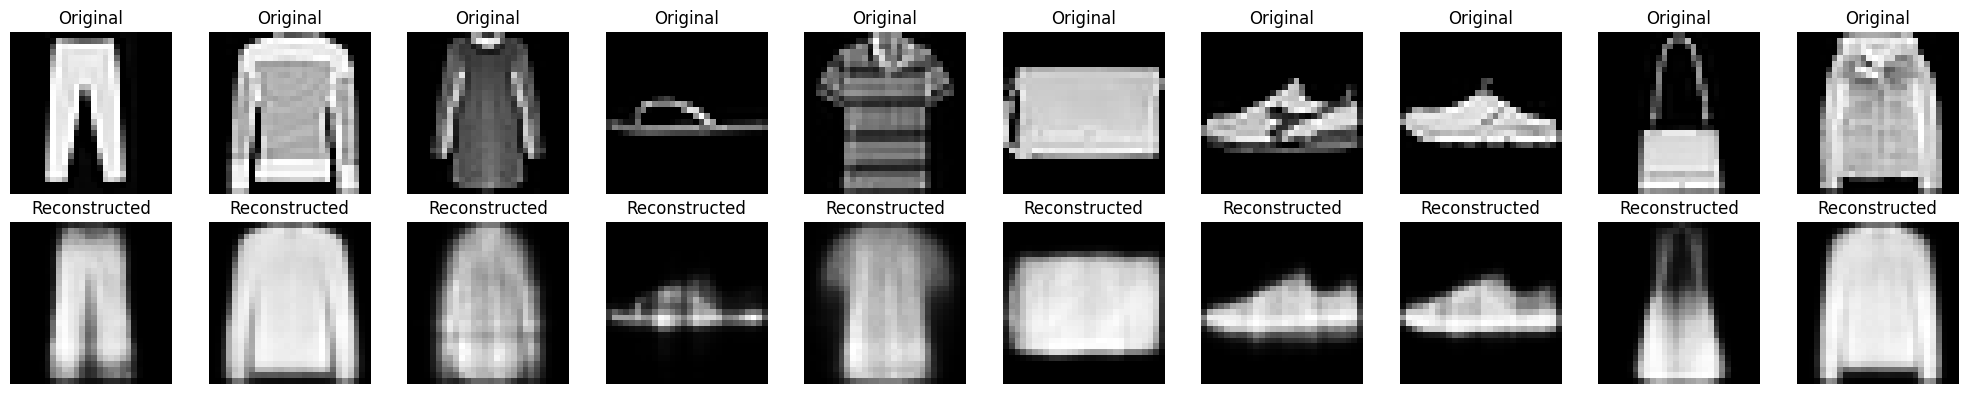

 61%|██████▏   | 19/31 [02:36<01:42,  8.58s/it]

Epoch: 19 | Training Loss: 259.42774
Epoch: 19 | Validation Loss: 260.11207


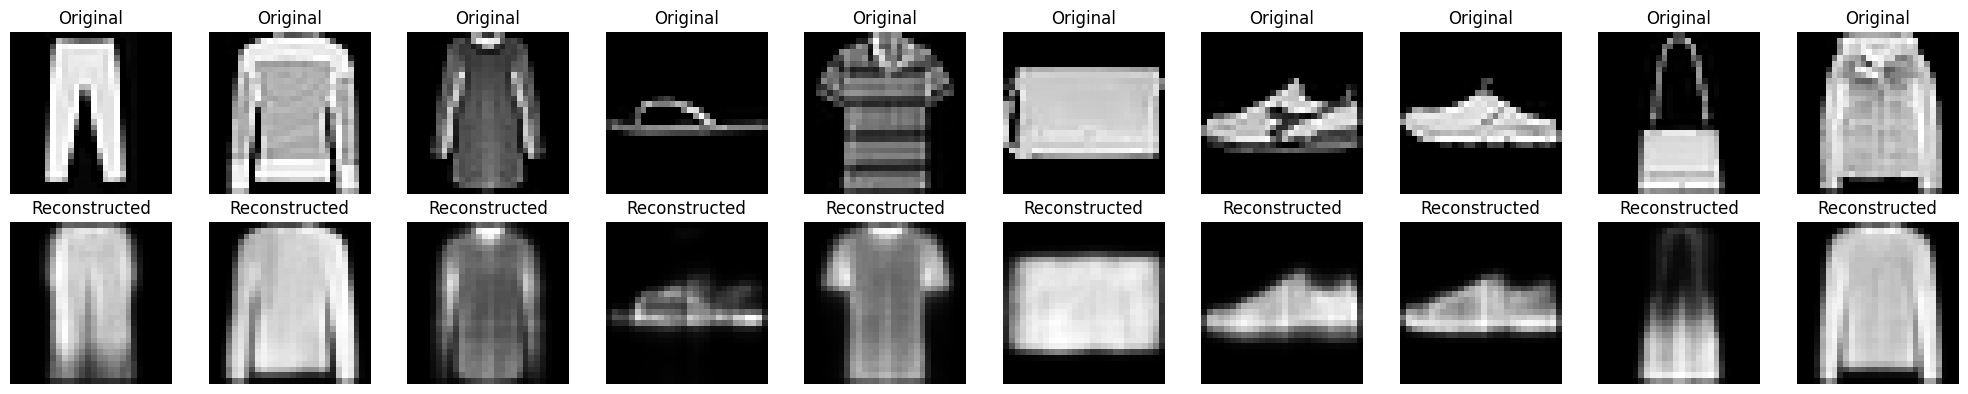

 65%|██████▍   | 20/31 [02:45<01:34,  8.55s/it]

Epoch: 20 | Training Loss: 257.99259
Epoch: 20 | Validation Loss: 258.74249


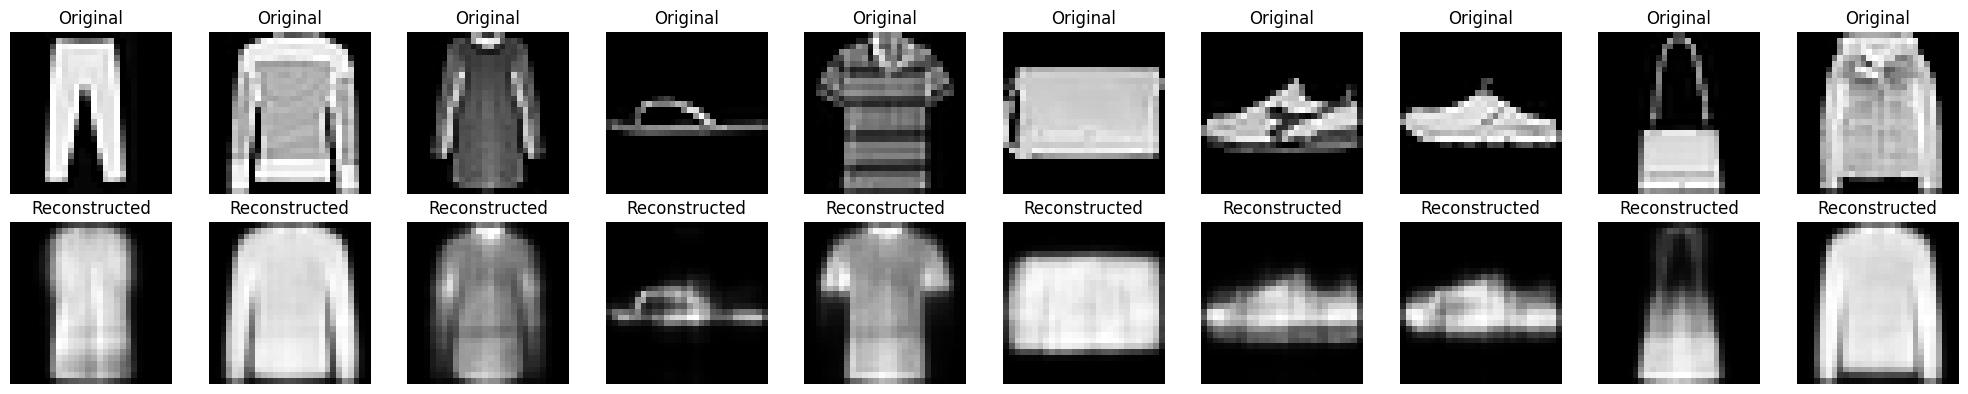

 68%|██████▊   | 21/31 [02:53<01:25,  8.60s/it]

Epoch: 21 | Training Loss: 257.13506
Epoch: 21 | Validation Loss: 255.64101


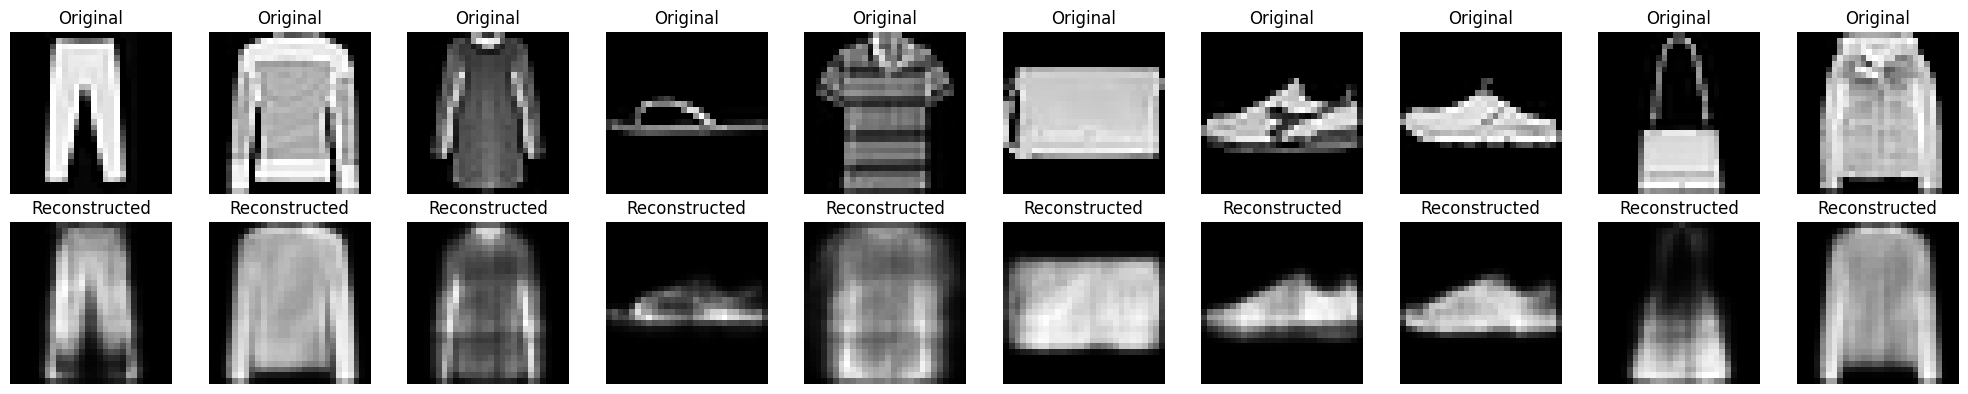

 71%|███████   | 22/31 [03:02<01:17,  8.60s/it]

Epoch: 22 | Training Loss: 256.45567
Epoch: 22 | Validation Loss: 260.20226


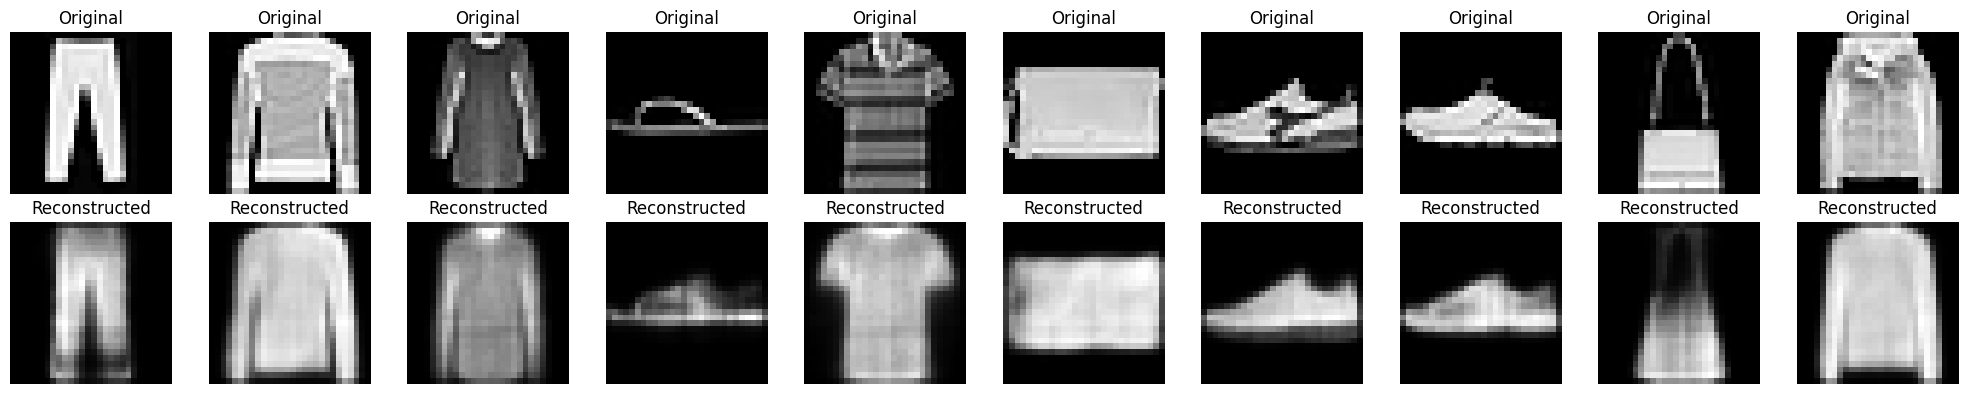

 74%|███████▍  | 23/31 [03:10<01:07,  8.43s/it]

Epoch: 23 | Training Loss: 255.58632
Epoch: 23 | Validation Loss: 253.04320


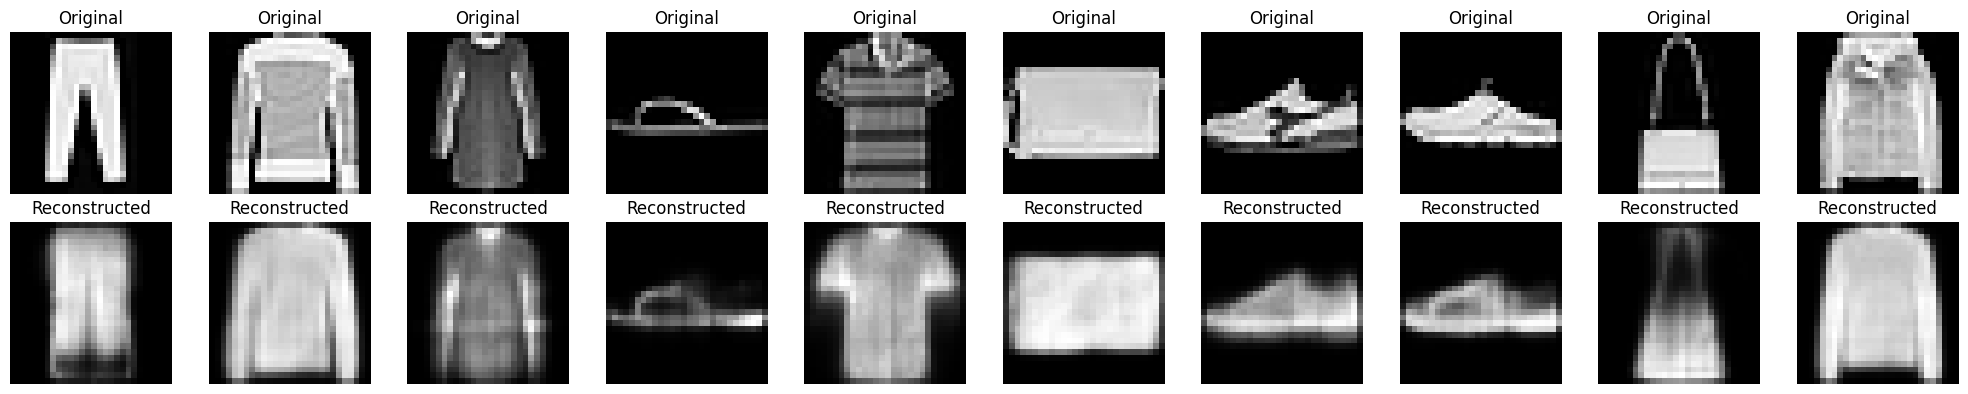

 77%|███████▋  | 24/31 [03:19<00:59,  8.54s/it]

Epoch: 24 | Training Loss: 254.26607
Epoch: 24 | Validation Loss: 253.18817


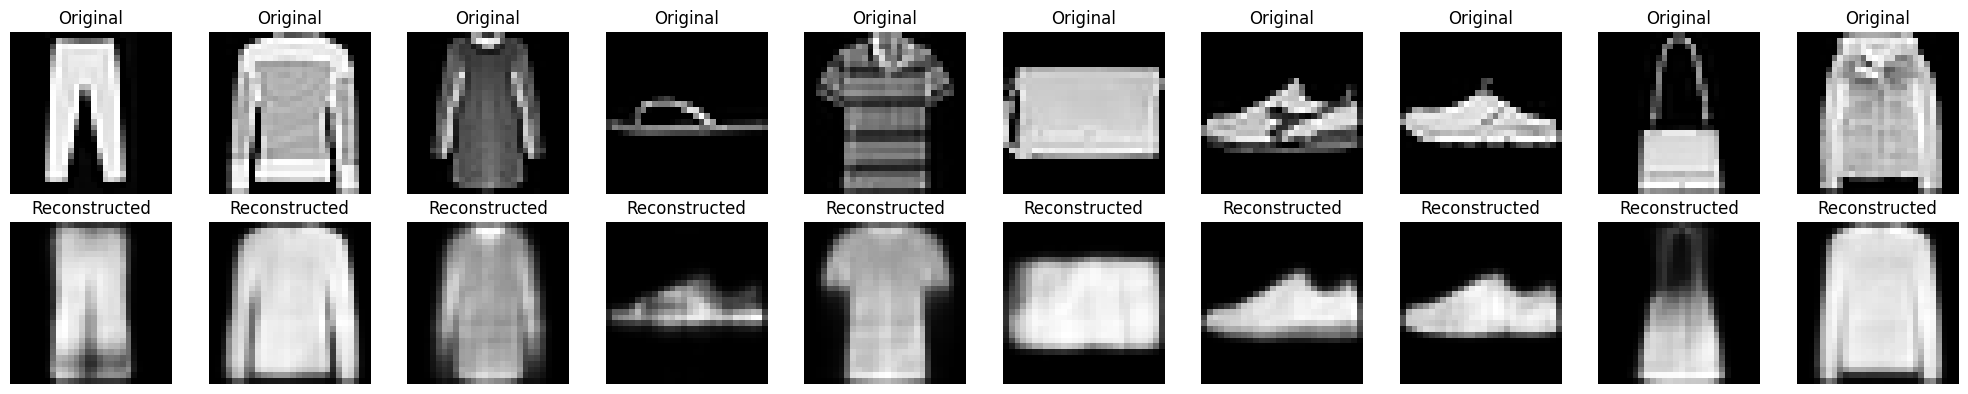

 81%|████████  | 25/31 [03:27<00:51,  8.54s/it]

Epoch: 25 | Training Loss: 253.86996
Epoch: 25 | Validation Loss: 253.53415


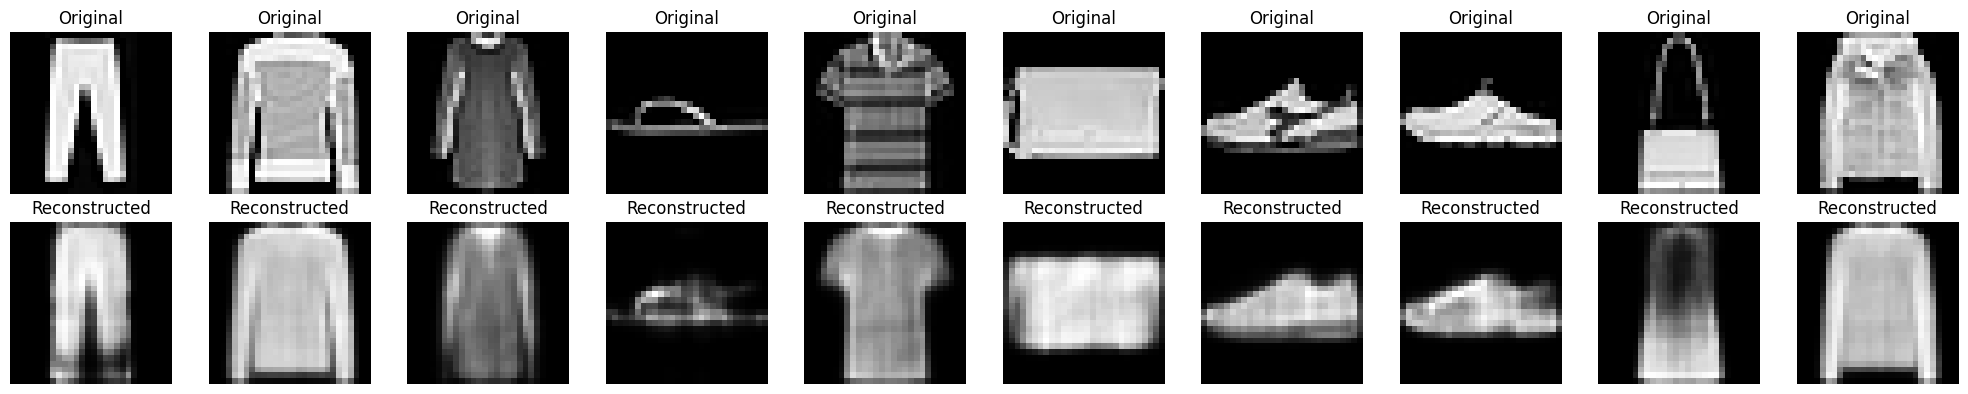

 84%|████████▍ | 26/31 [03:36<00:42,  8.52s/it]

Epoch: 26 | Training Loss: 253.00020
Epoch: 26 | Validation Loss: 251.12613


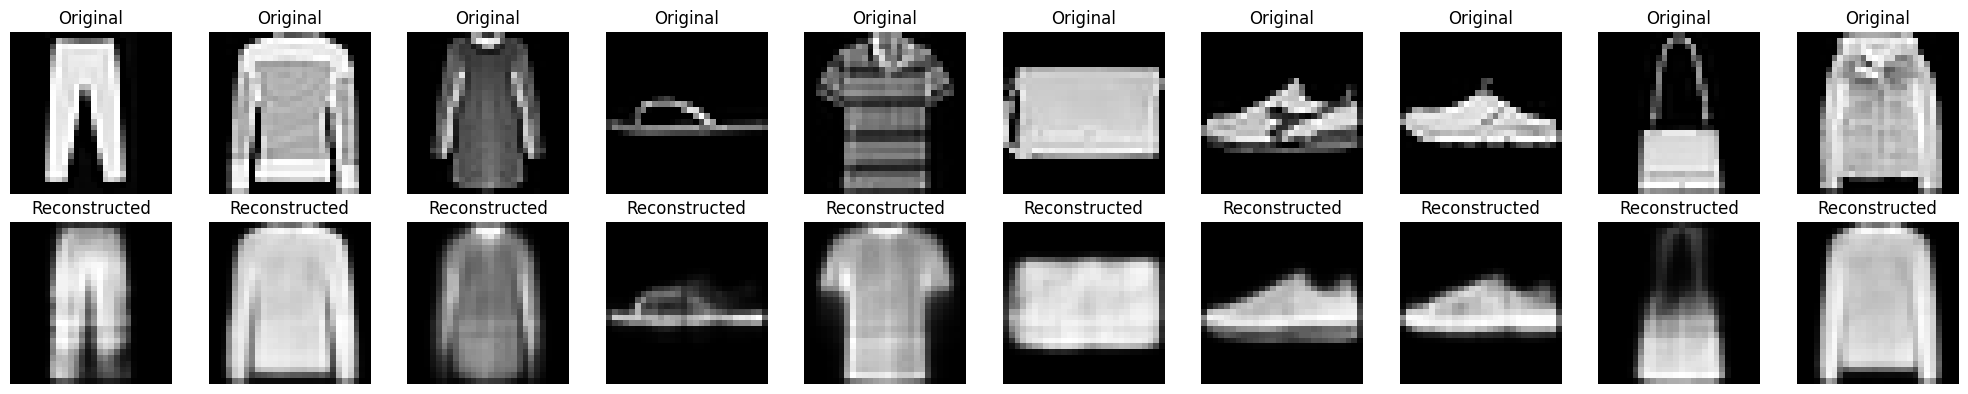

 87%|████████▋ | 27/31 [03:45<00:34,  8.59s/it]

Epoch: 27 | Training Loss: 252.67136
Epoch: 27 | Validation Loss: 250.60812


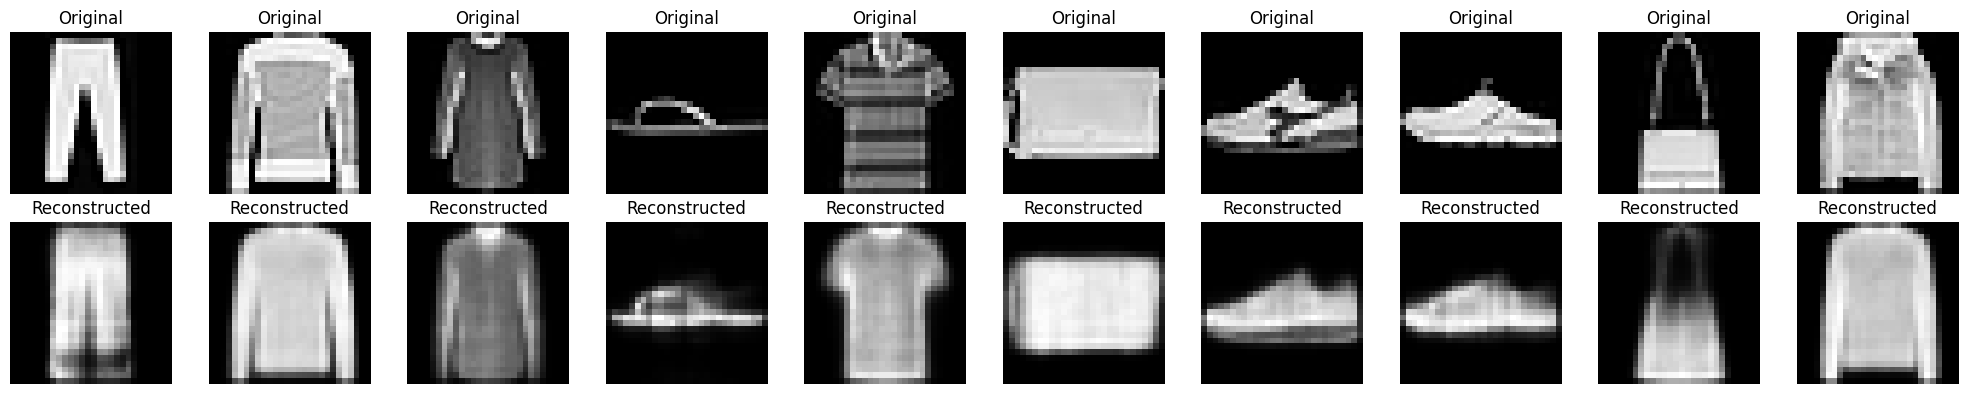

 90%|█████████ | 28/31 [03:53<00:25,  8.60s/it]

Epoch: 28 | Training Loss: 252.54181
Epoch: 28 | Validation Loss: 250.21761


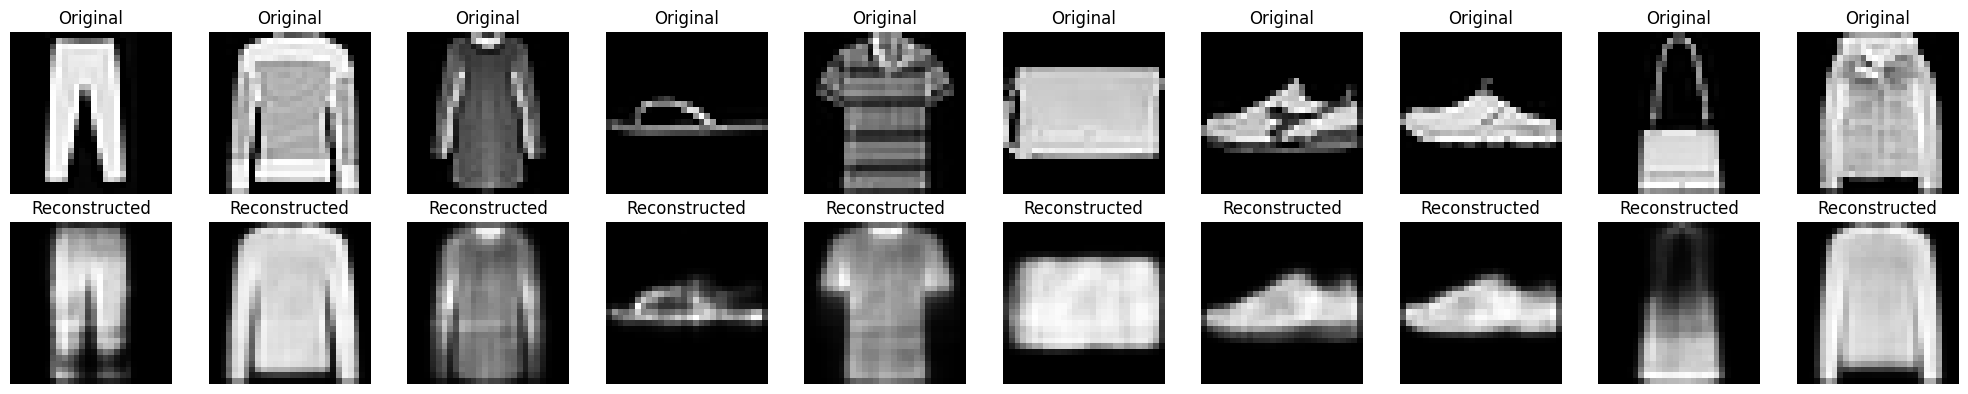

 94%|█████████▎| 29/31 [04:01<00:16,  8.40s/it]

Epoch: 29 | Training Loss: 251.77124
Epoch: 29 | Validation Loss: 250.35050


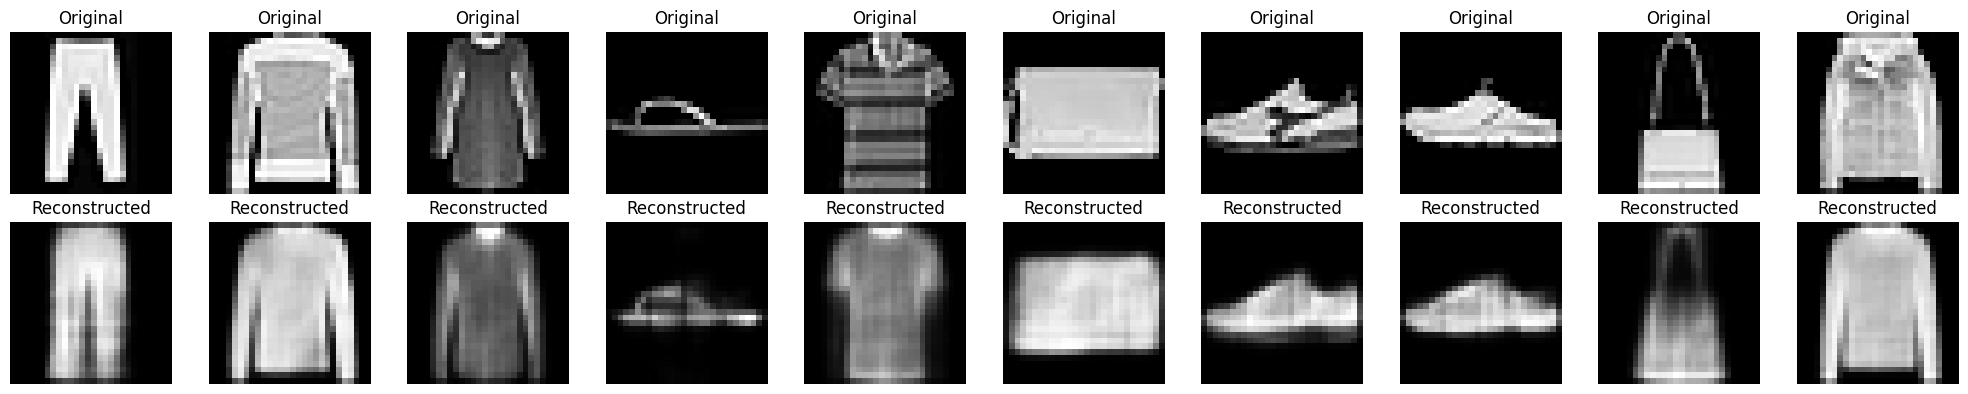

 97%|█████████▋| 30/31 [04:10<00:08,  8.50s/it]

Epoch: 30 | Training Loss: 251.49847
Epoch: 30 | Validation Loss: 252.31152


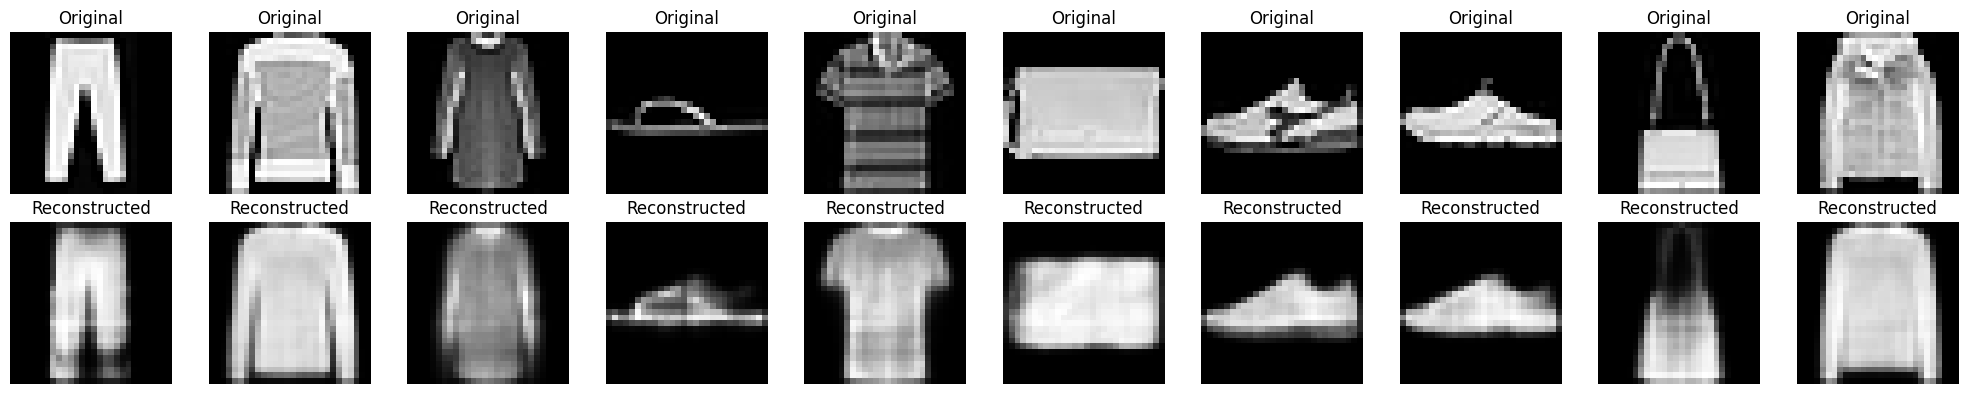

100%|██████████| 31/31 [04:18<00:00,  8.35s/it]


In [115]:
train_losses, val_losses, latent_params = train(train_dl, valid_dl, model, optimizer, epochs, device)

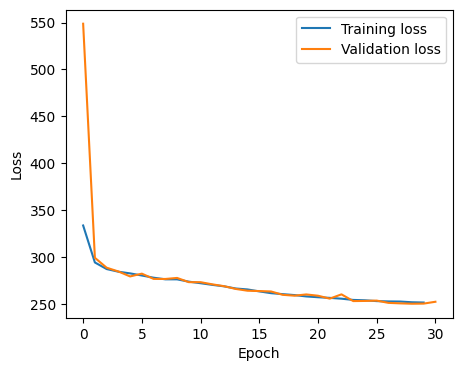

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

ax.plot(train_losses, label="Training loss")
ax.plot(val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

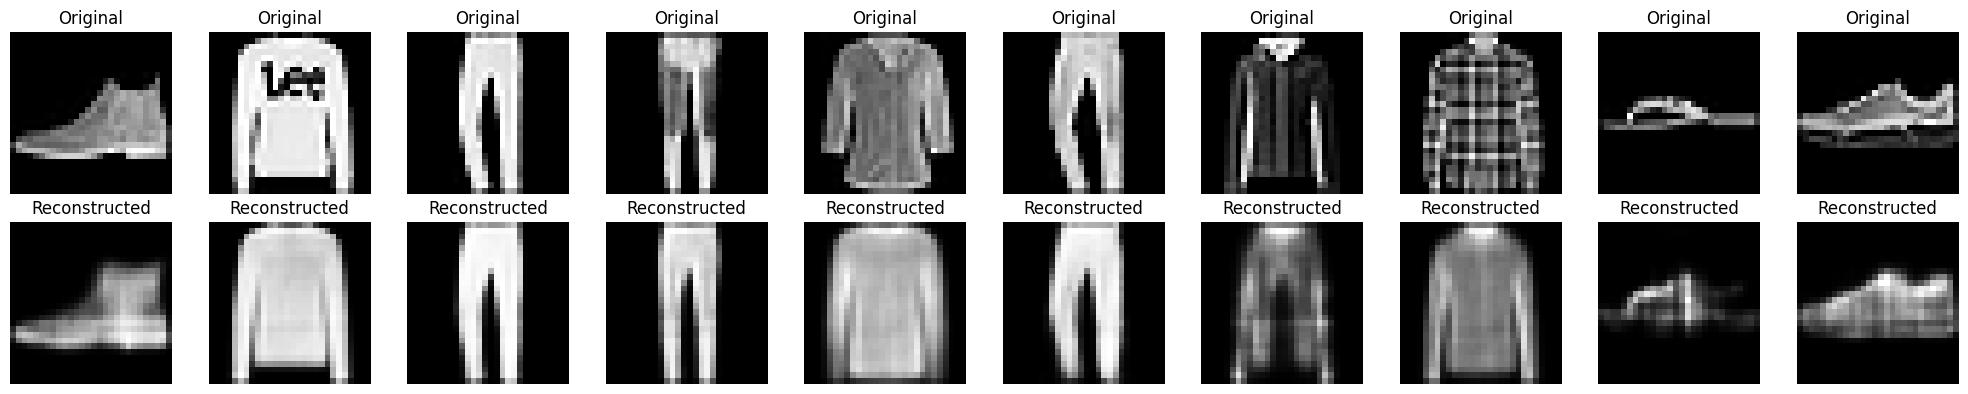

In [117]:
test_images, _ = next(iter(test_dl))
X_test_hat, _, _ = model(test_images.to(device))
display_images(test_images, X_test_hat)

In [118]:
len(latent_params["means"])

31

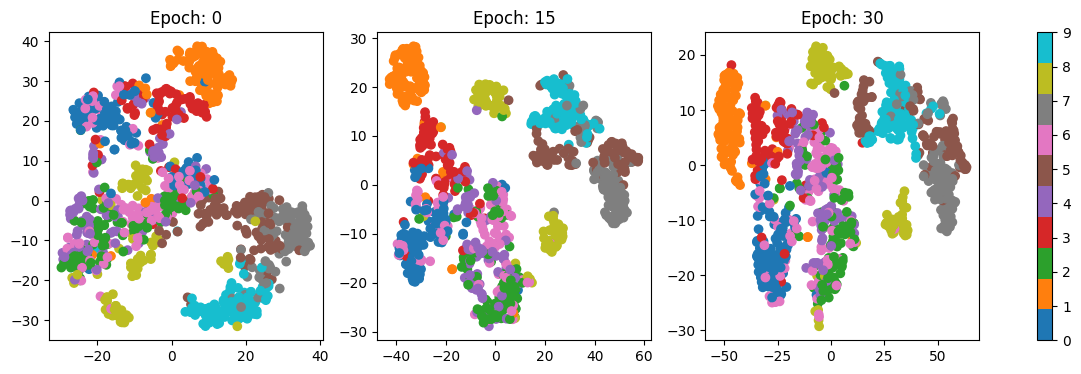

In [119]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(15, 4), squeeze=True)

N = 1000
epochs = (0, 15, 30)

for i, epoch in enumerate(epochs):

    tsne_embeds = TSNE(n_components=2).fit_transform(latent_params["means"][epoch][:N])

    labels = latent_params["labels"][epoch][:N]
    g = axes[i].scatter(tsne_embeds[:, 0], tsne_embeds[:, 1], c=labels, cmap="tab10")
    axes[i].set_title(f"Epoch: {epoch}")

fig.colorbar(g, ax=axes[:])
plt.show()

## **Using decoder as generative model**

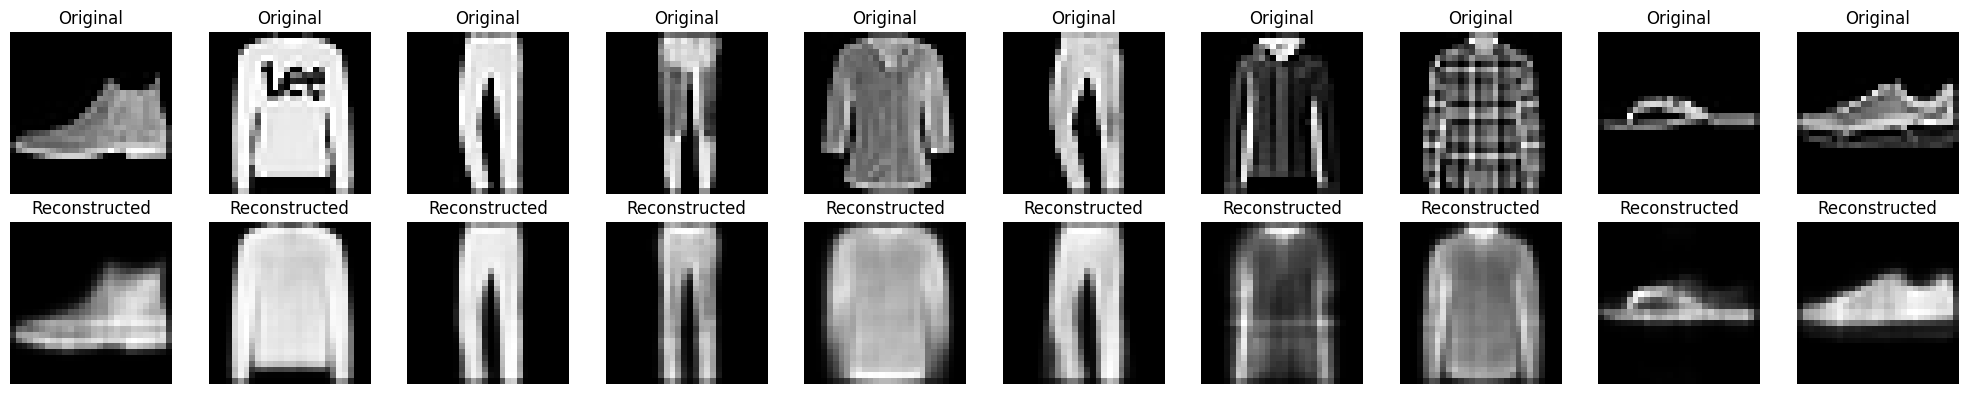

In [120]:
# Generate mu and logvar using the trained model
_, mu, logvar = model(test_images.to(device))

# Generate samples from latent space
std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
sample = mu + (std * eps)

# Generate new images
new_images = model.decoder(sample)

# Visualize the input and output images
display_images(test_images, new_images)

## **VAE with CNN**

In [121]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        # out feature map size of 14 x 14
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=32, kernel_size=4, stride=2, padding=1)

        # out feature map size of 7 x 7
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1)

        # Fully-connected linear layer to map to latent space
        self.fc_mu = nn.Linear(in_features=7*7*64, out_features=32)
        self.fc_logvar = nn.Linear(in_features=7*7*64, out_features=32)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = x.view(x.shape[0], -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

In [122]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Map out latent space to first decoder FC layer
        self.fc = nn.Linear(in_features=32, out_features=64*7*7)

        # Deconvolute FC layer to 14x14 feature map with 32 channels using
        # 64 4 x 4 kernels
        self.deconv1 = nn.ConvTranspose2d(
            in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1)

        # Deconvolute FC layer to 28x28 feature maps with 1 channel using
        # 32 4 x 4 kernels
        self.deconv2 = nn.ConvTranspose2d(
            in_channels=32, out_channels=1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):

        x = self.fc(x)

        x = x.view(x.shape[0], 64, 7, 7)

        x = F.relu(self.deconv1(x))
        x = torch.sigmoid(self.deconv2(x))

        return x

In [123]:
class ConVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)

        return sample

    def forward(self, x):

        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)

        return x_hat, mu, logvar


In [124]:
model = ConVAE().to(device)

print(model)

ConVAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc_mu): Linear(in_features=3136, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=3136, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=3136, bias=True)
    (deconv1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (deconv2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)


In [125]:
epochs = 30
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch: 0 | Validation Loss: 569.69955


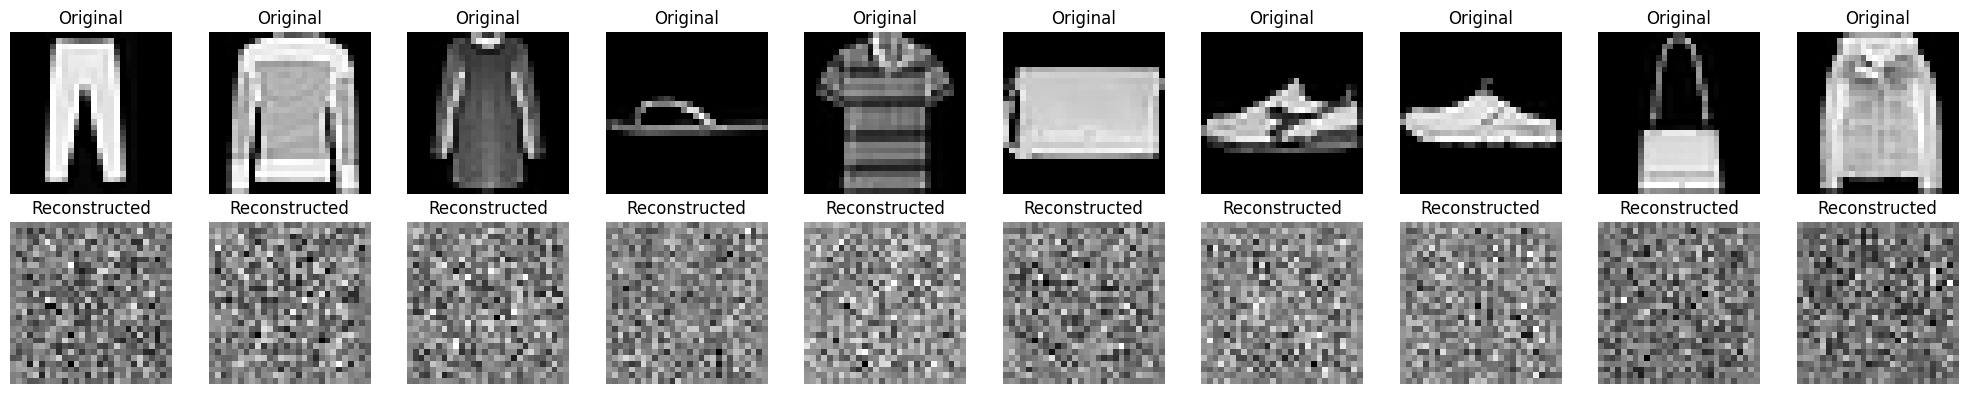

  3%|▎         | 1/31 [00:01<00:54,  1.80s/it]

Epoch: 1 | Training Loss: 287.18113
Epoch: 1 | Validation Loss: 258.99166


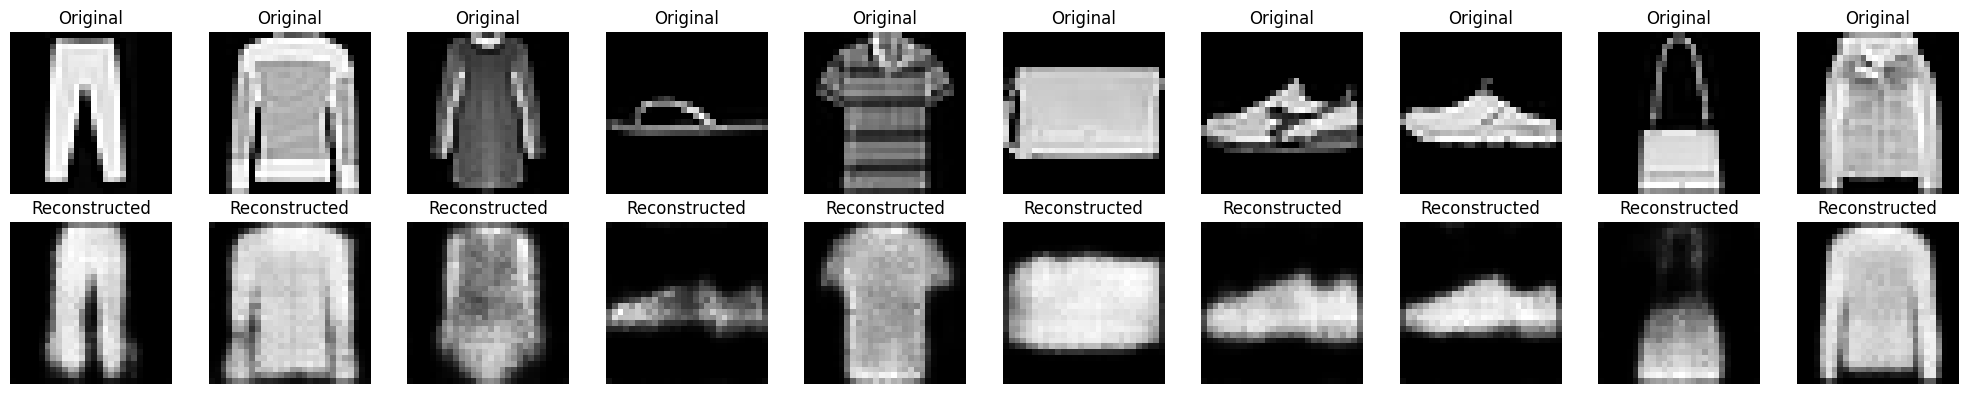

  6%|▋         | 2/31 [00:11<02:58,  6.16s/it]

Epoch: 2 | Training Loss: 255.38303
Epoch: 2 | Validation Loss: 251.45043


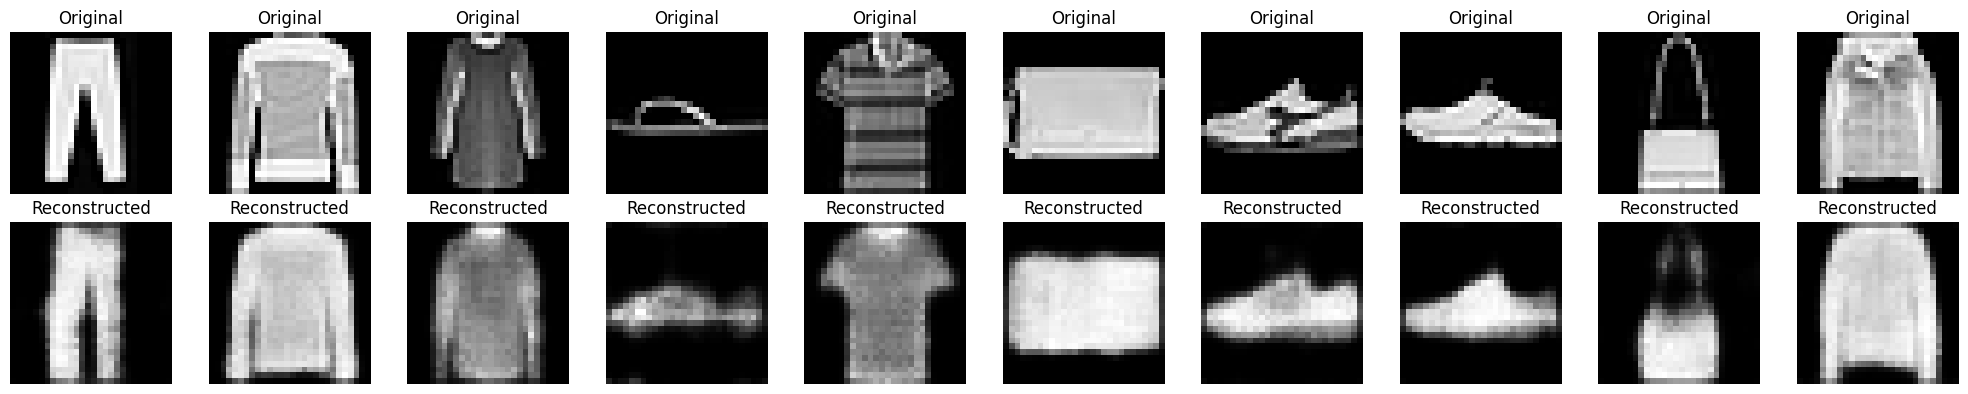

 10%|▉         | 3/31 [00:19<03:22,  7.22s/it]

Epoch: 3 | Training Loss: 250.68460
Epoch: 3 | Validation Loss: 248.17611


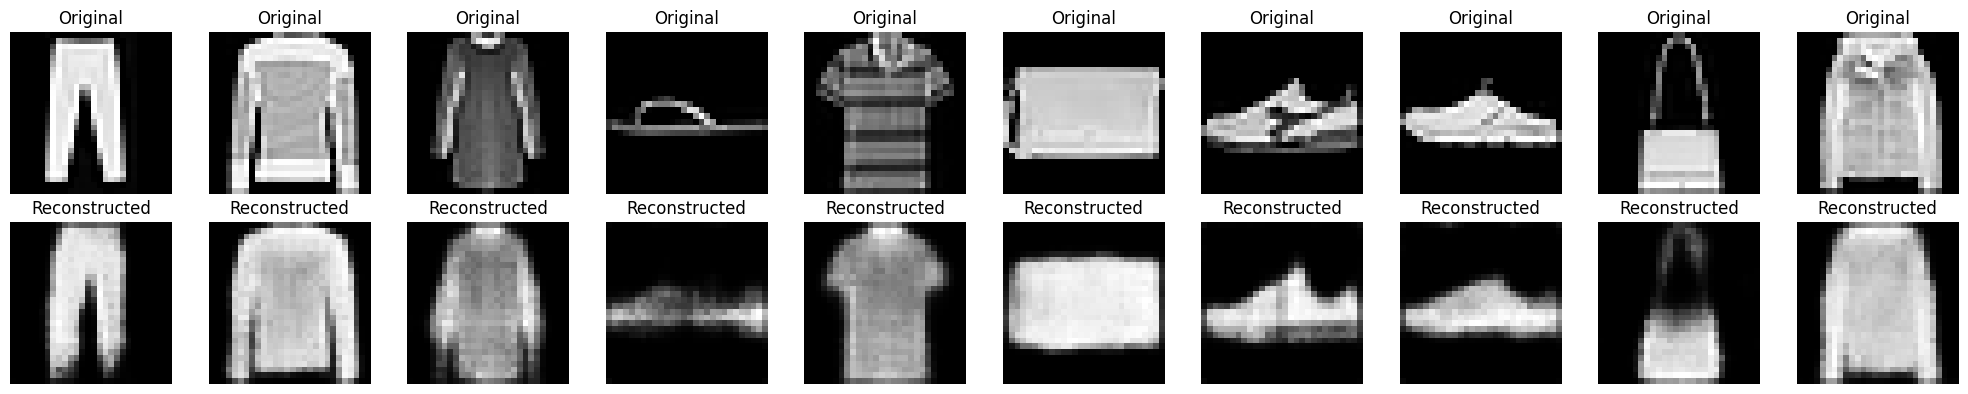

 13%|█▎        | 4/31 [00:28<03:35,  8.00s/it]

Epoch: 4 | Training Loss: 248.25322
Epoch: 4 | Validation Loss: 246.82856


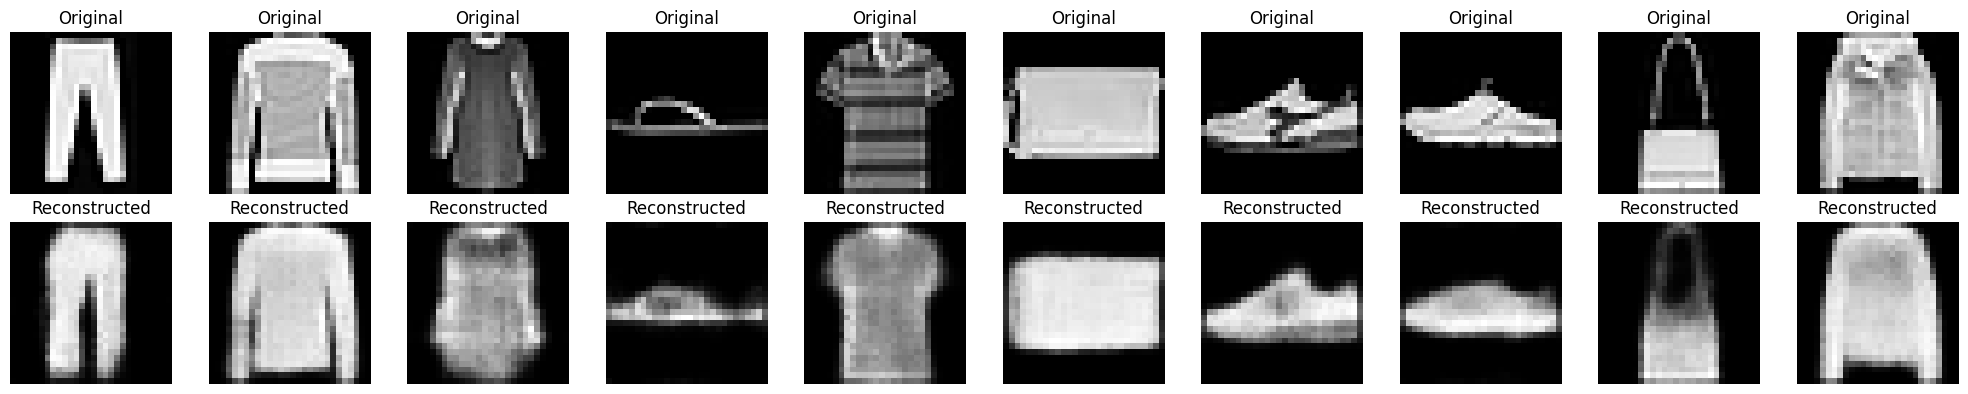

 16%|█▌        | 5/31 [00:38<03:45,  8.66s/it]

Epoch: 5 | Training Loss: 246.72457
Epoch: 5 | Validation Loss: 245.54555


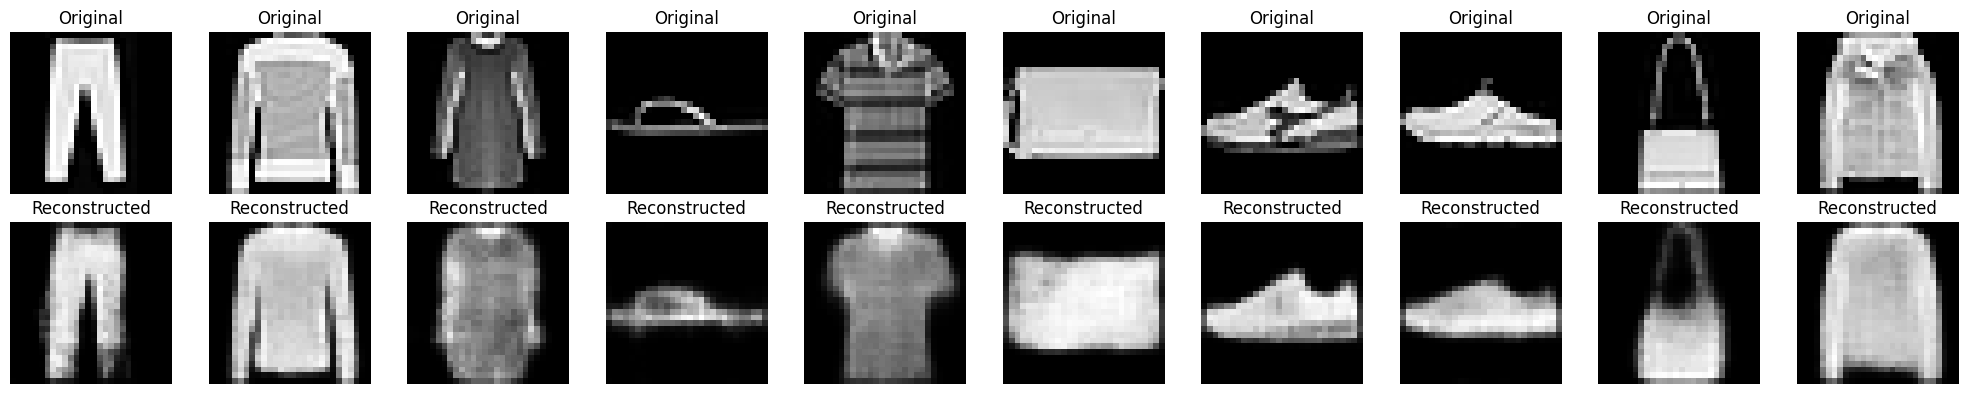

 19%|█▉        | 6/31 [00:47<03:42,  8.89s/it]

Epoch: 6 | Training Loss: 245.60684
Epoch: 6 | Validation Loss: 244.57446


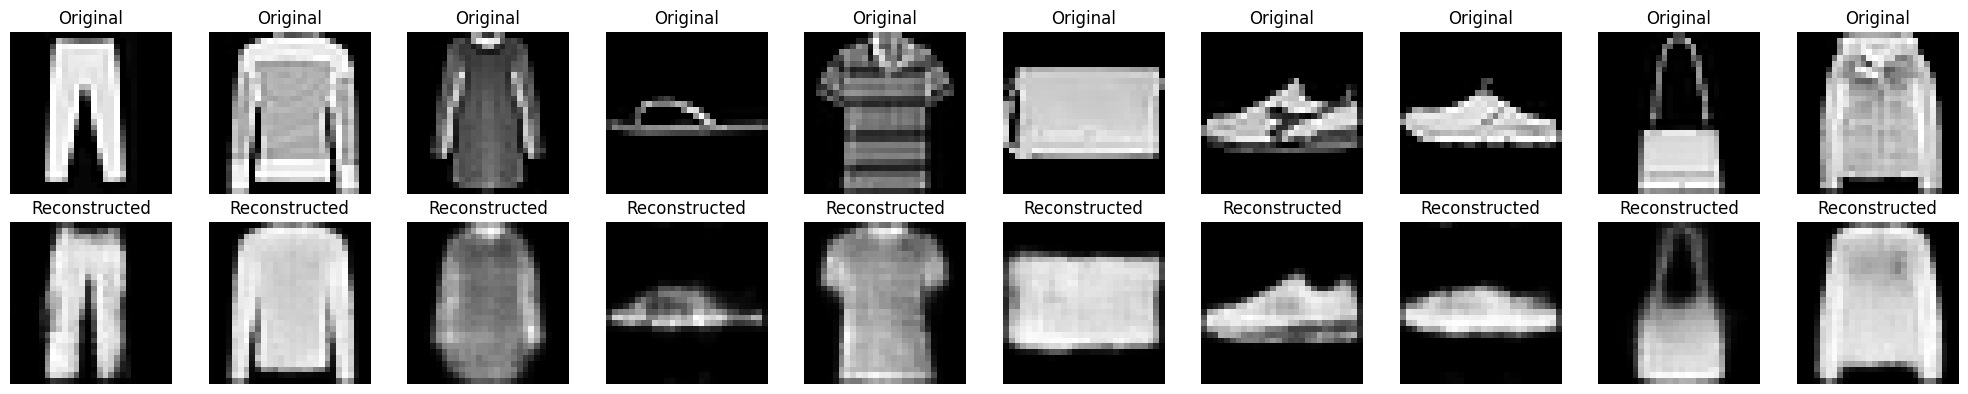

 23%|██▎       | 7/31 [00:56<03:30,  8.78s/it]

Epoch: 7 | Training Loss: 244.82776
Epoch: 7 | Validation Loss: 243.88110


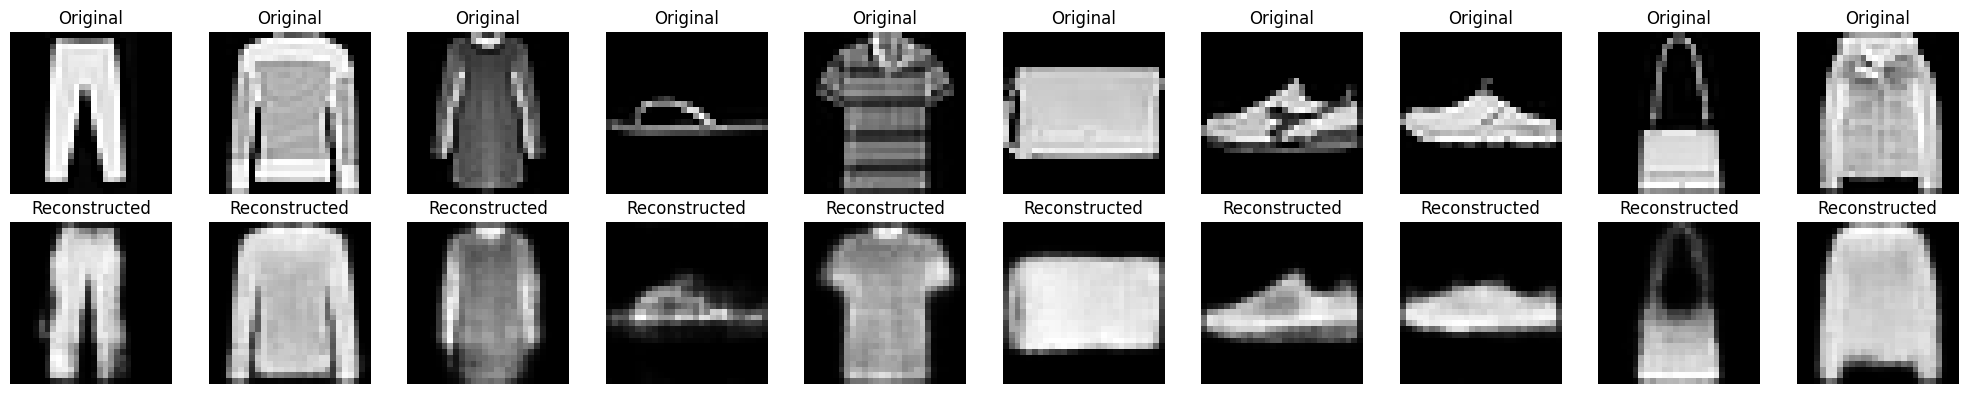

 26%|██▌       | 8/31 [01:05<03:26,  8.96s/it]

Epoch: 8 | Training Loss: 244.15960
Epoch: 8 | Validation Loss: 243.32358


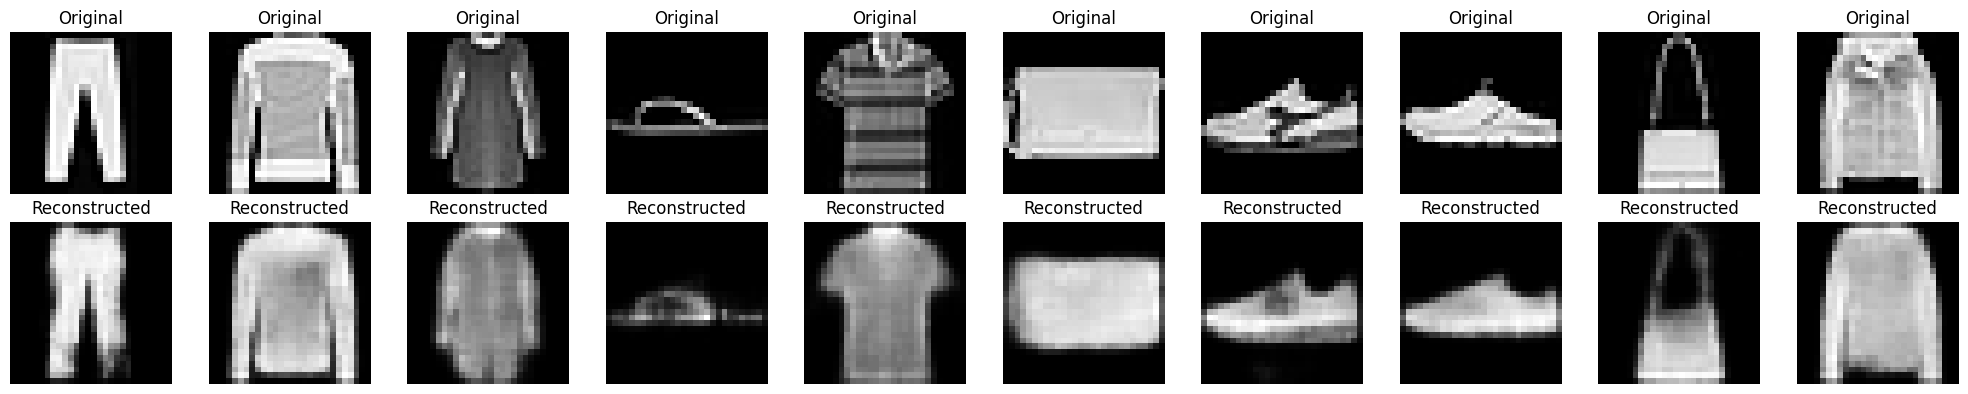

 29%|██▉       | 9/31 [01:15<03:19,  9.09s/it]

Epoch: 9 | Training Loss: 243.56610
Epoch: 9 | Validation Loss: 242.62737


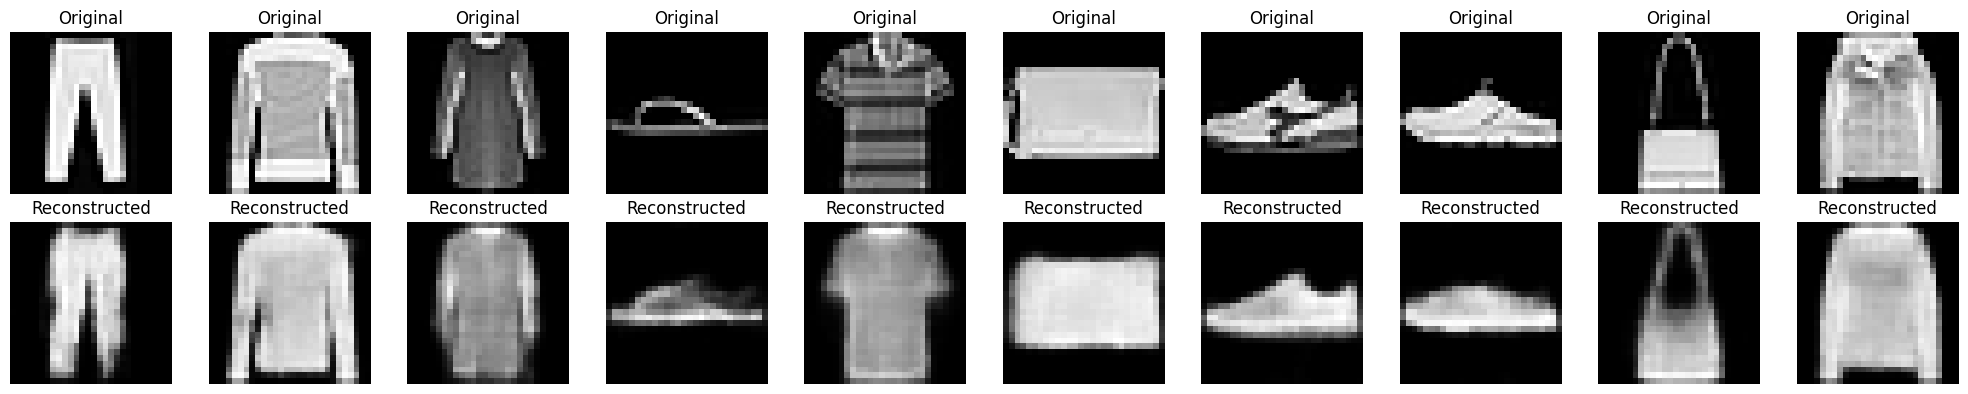

 32%|███▏      | 10/31 [01:24<03:11,  9.14s/it]

Epoch: 10 | Training Loss: 243.15296
Epoch: 10 | Validation Loss: 242.07676


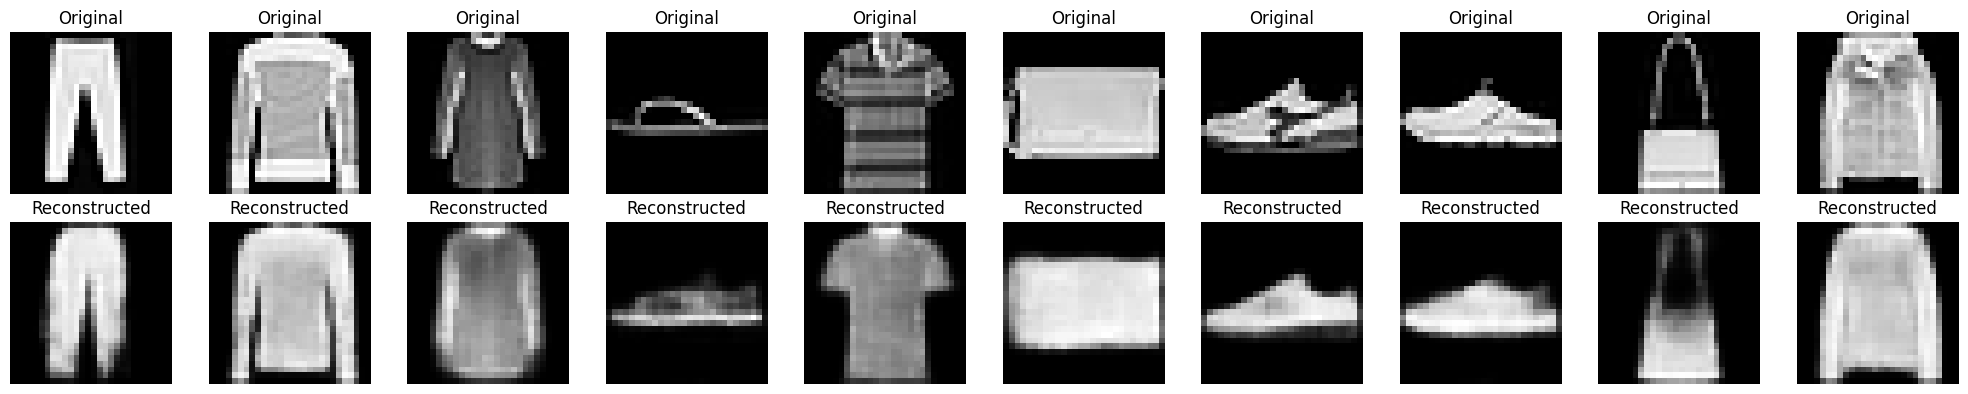

 35%|███▌      | 11/31 [01:34<03:10,  9.51s/it]

Epoch: 11 | Training Loss: 242.75068
Epoch: 11 | Validation Loss: 242.07452


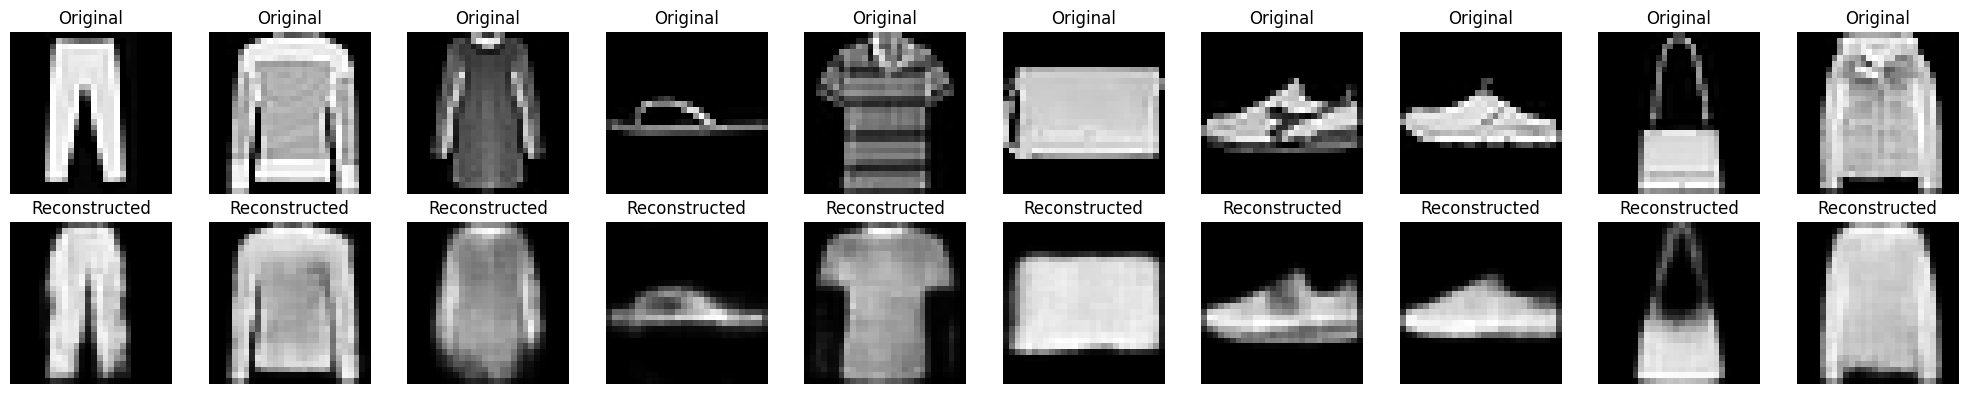

 39%|███▊      | 12/31 [01:43<02:58,  9.42s/it]

Epoch: 12 | Training Loss: 242.43317
Epoch: 12 | Validation Loss: 241.63316


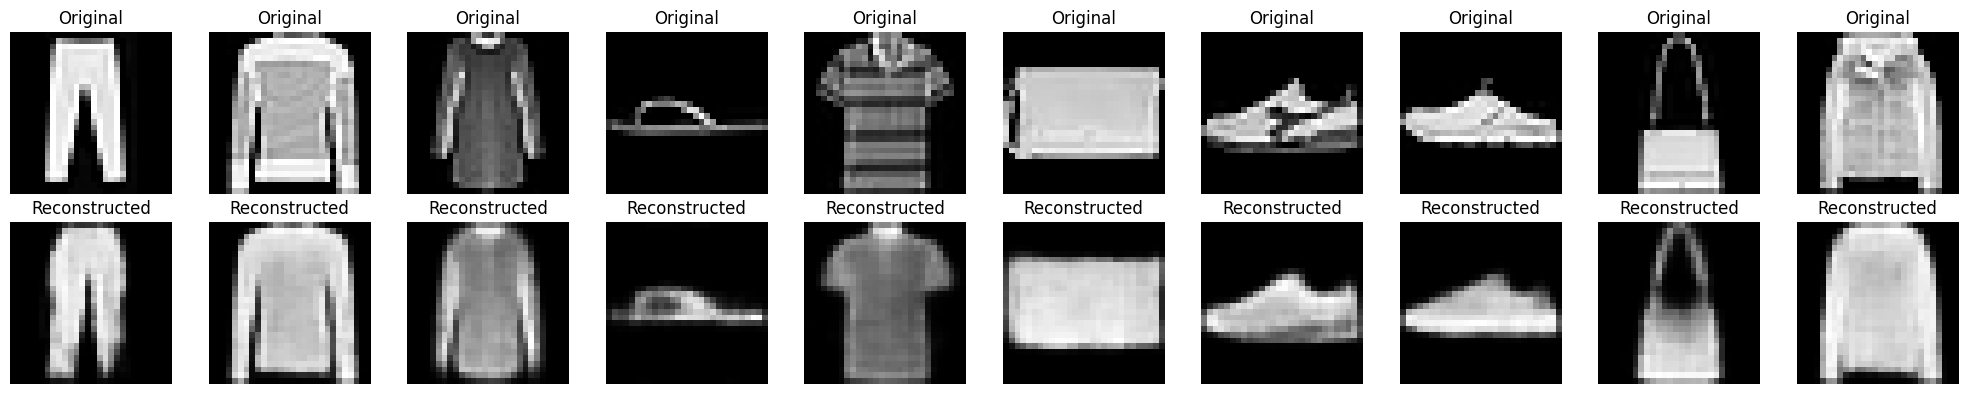

 42%|████▏     | 13/31 [01:53<02:48,  9.37s/it]

Epoch: 13 | Training Loss: 242.19021
Epoch: 13 | Validation Loss: 241.18840


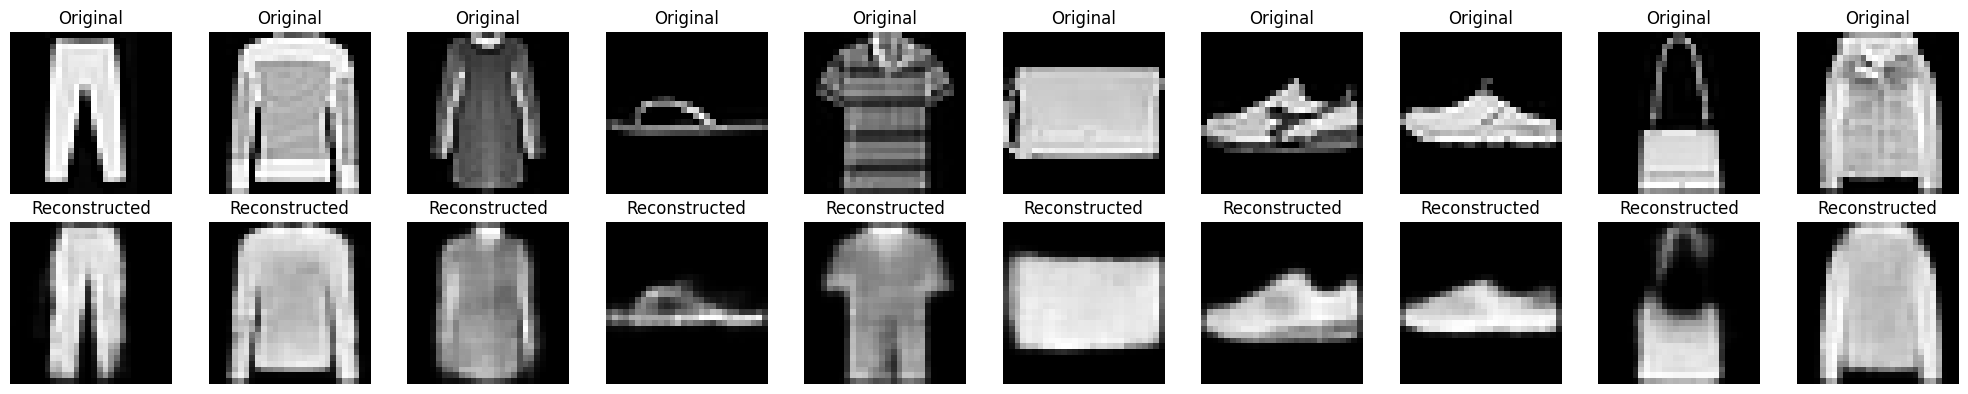

 45%|████▌     | 14/31 [02:02<02:39,  9.37s/it]

Epoch: 14 | Training Loss: 241.91318
Epoch: 14 | Validation Loss: 241.08212


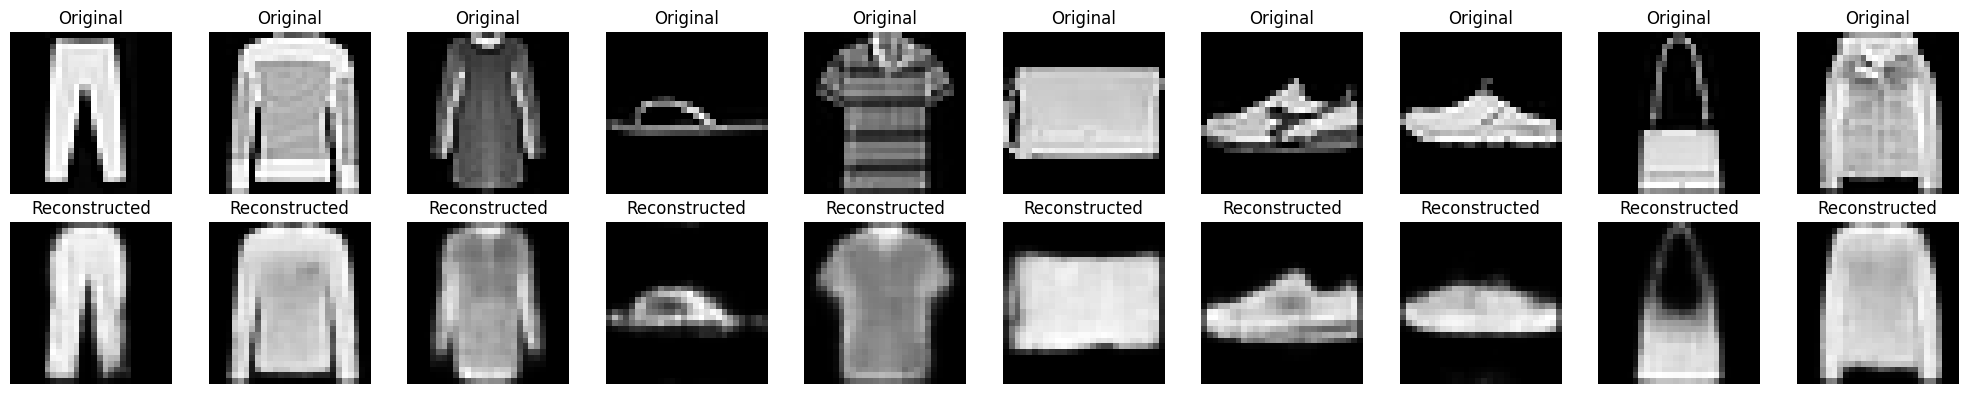

 48%|████▊     | 15/31 [02:11<02:26,  9.16s/it]

Epoch: 15 | Training Loss: 241.67701
Epoch: 15 | Validation Loss: 240.74511


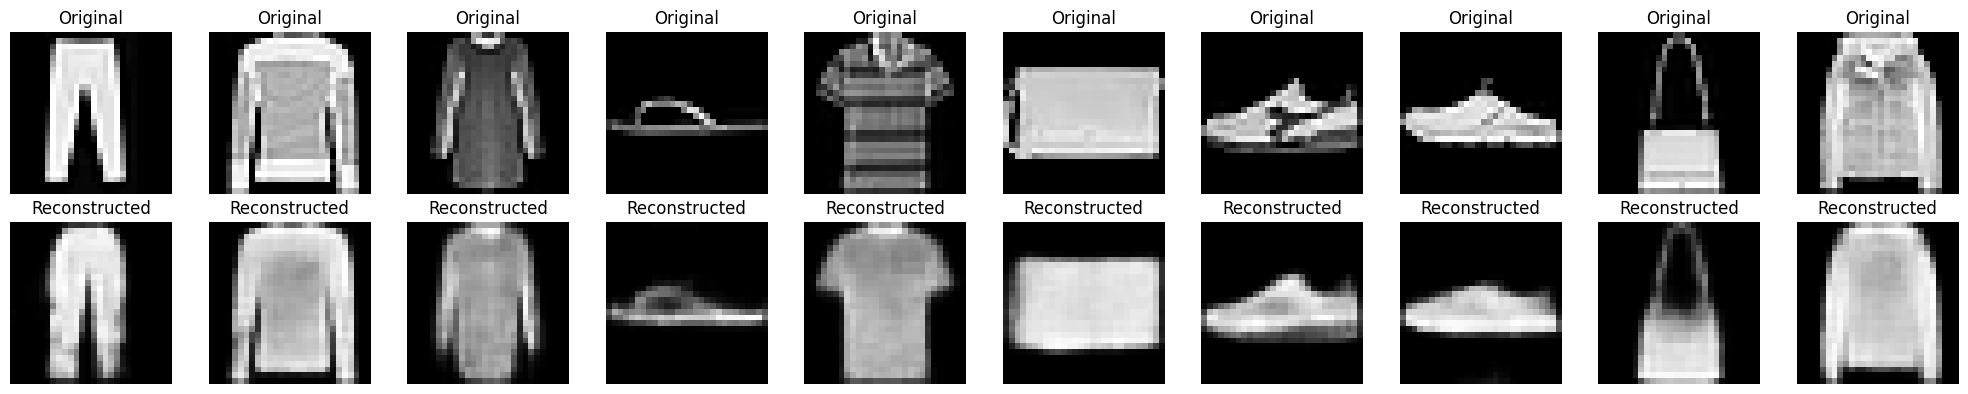

 52%|█████▏    | 16/31 [02:20<02:19,  9.32s/it]

Epoch: 16 | Training Loss: 241.45564
Epoch: 16 | Validation Loss: 240.84783


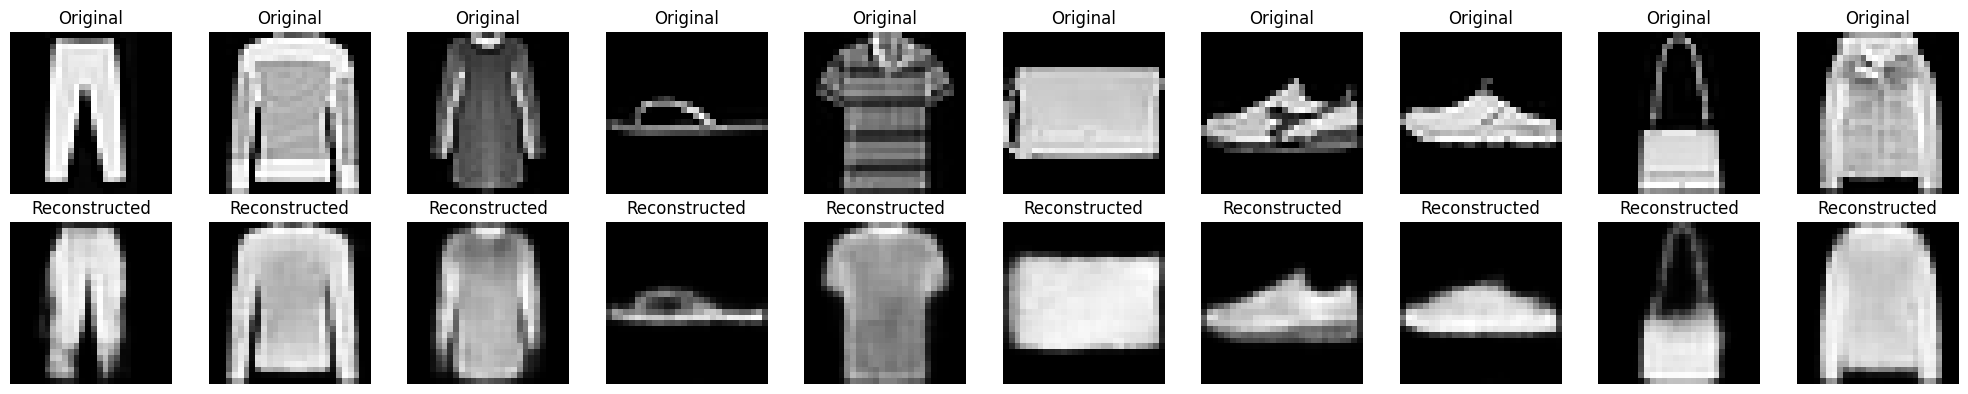

 55%|█████▍    | 17/31 [02:32<02:17,  9.85s/it]

Epoch: 17 | Training Loss: 241.23646
Epoch: 17 | Validation Loss: 240.56249


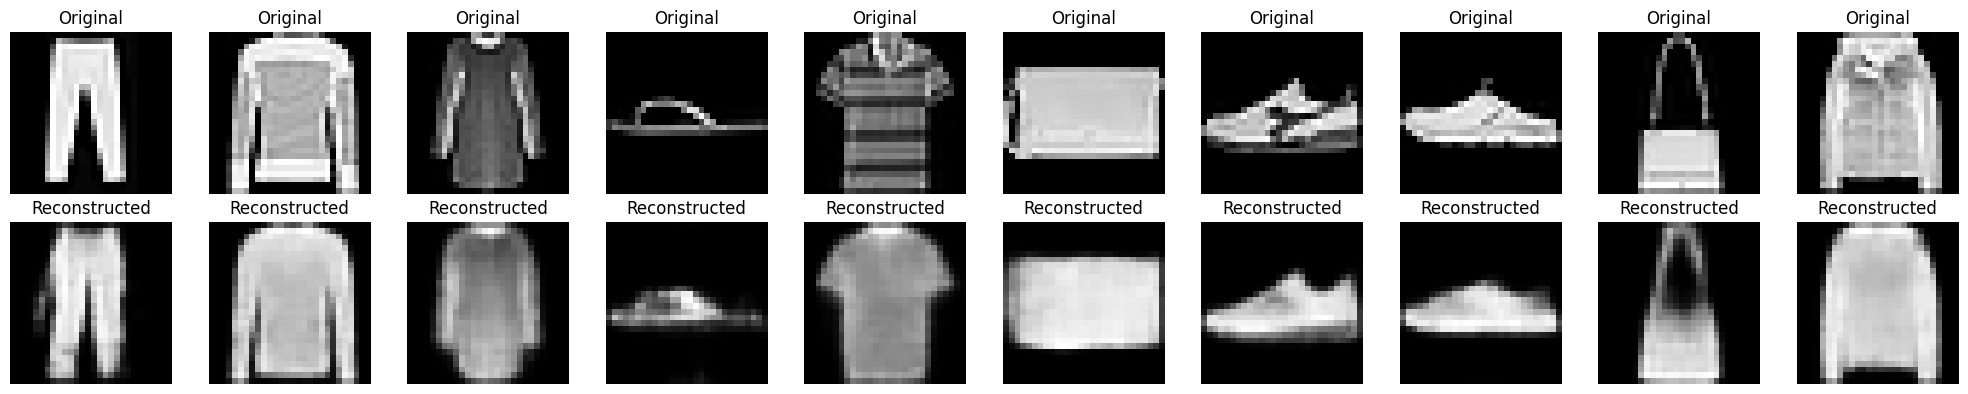

 58%|█████▊    | 18/31 [02:41<02:06,  9.72s/it]

Epoch: 18 | Training Loss: 241.09051
Epoch: 18 | Validation Loss: 240.49854


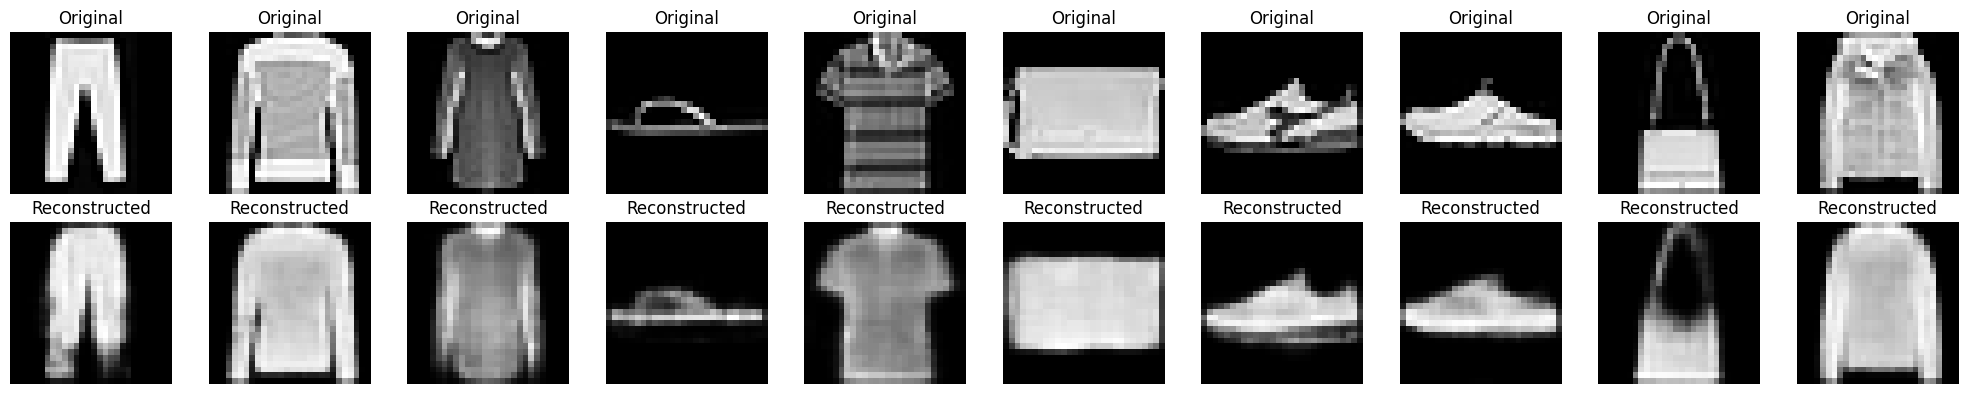

 61%|██████▏   | 19/31 [02:50<01:53,  9.44s/it]

Epoch: 19 | Training Loss: 240.92191
Epoch: 19 | Validation Loss: 240.28147


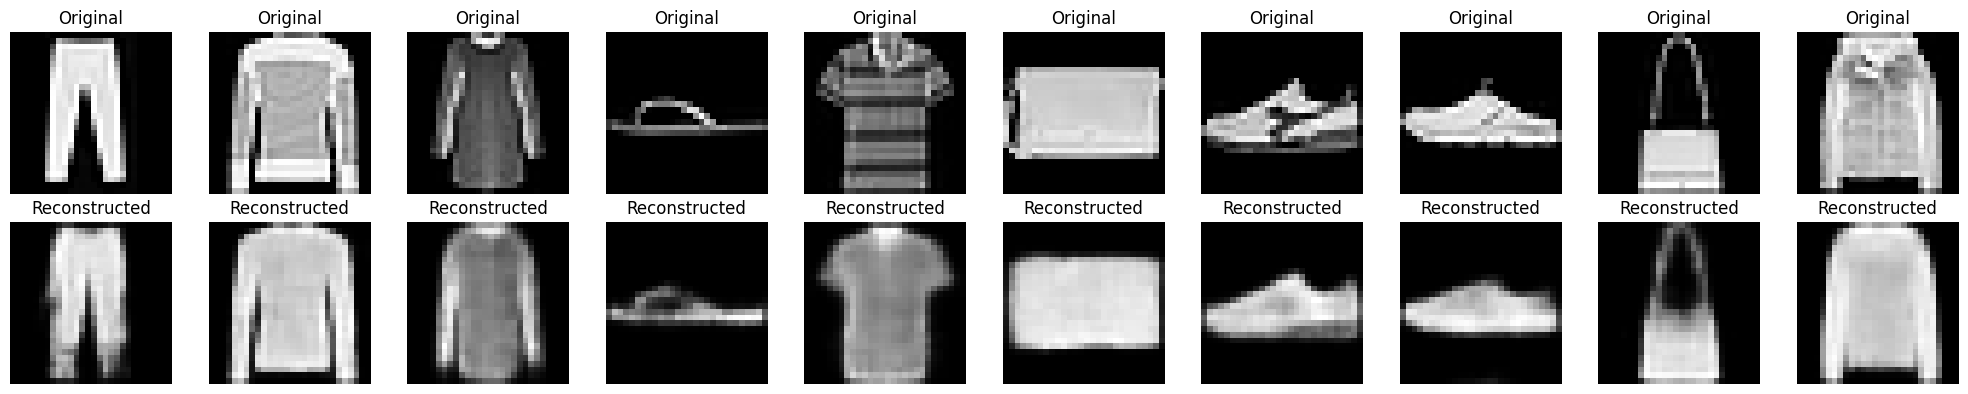

 65%|██████▍   | 20/31 [02:59<01:42,  9.36s/it]

Epoch: 20 | Training Loss: 240.73780
Epoch: 20 | Validation Loss: 240.13916


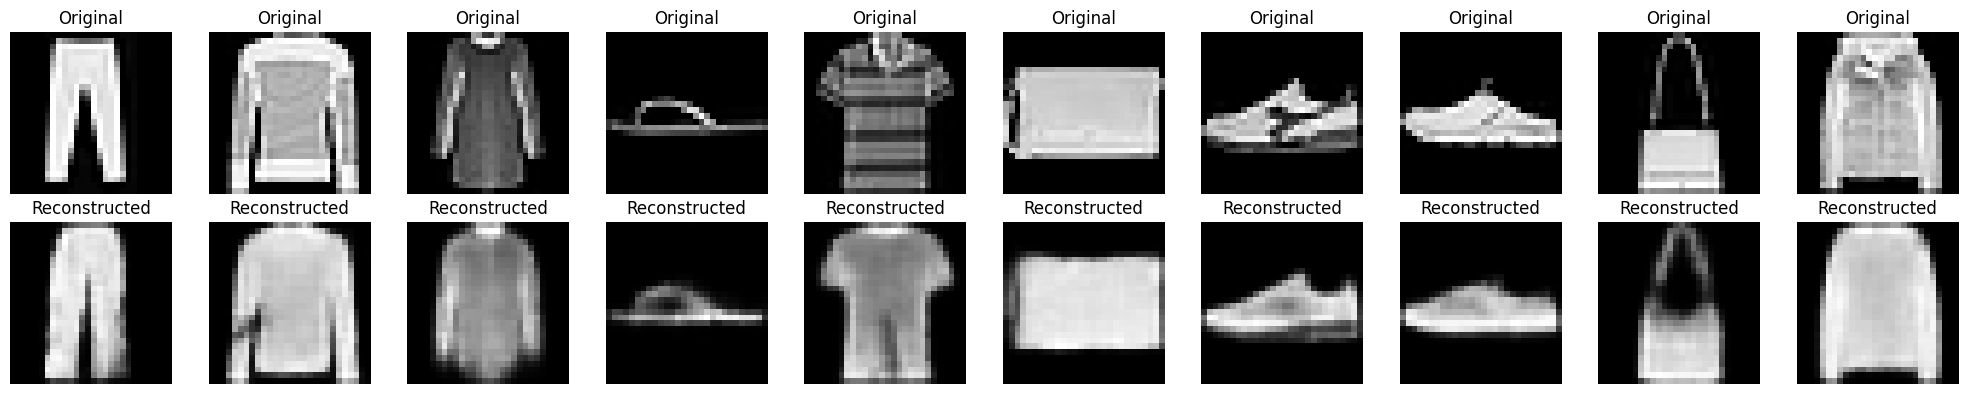

 68%|██████▊   | 21/31 [03:08<01:33,  9.36s/it]

Epoch: 21 | Training Loss: 240.63343
Epoch: 21 | Validation Loss: 240.00931


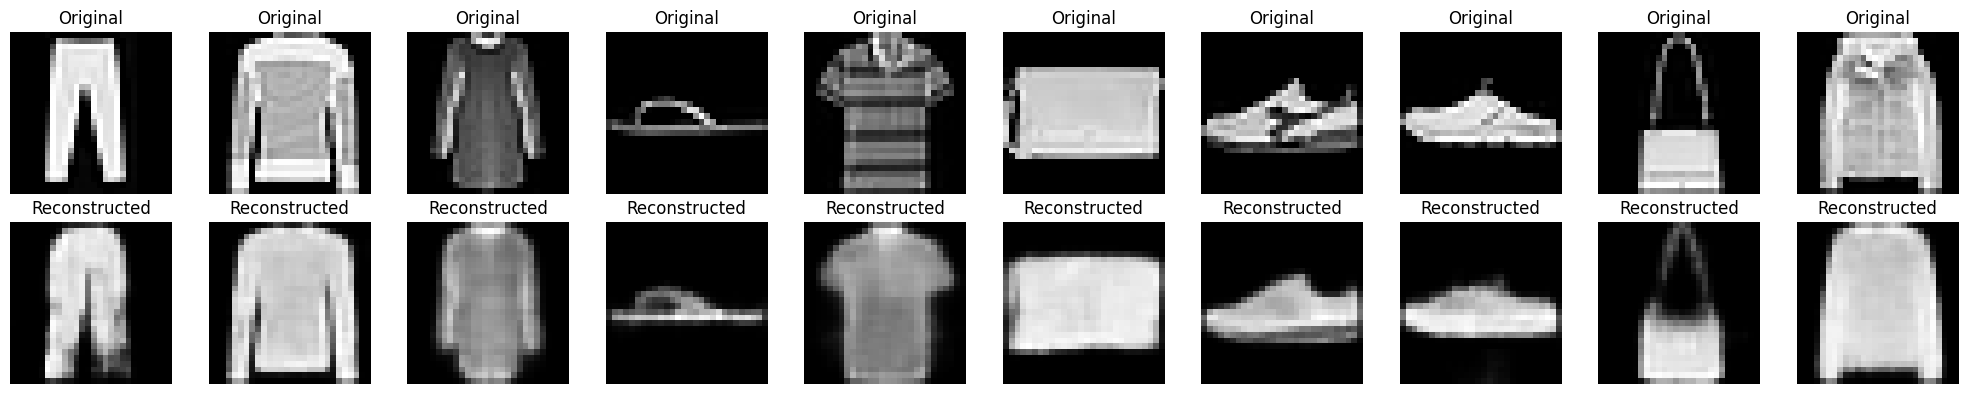

 71%|███████   | 22/31 [03:18<01:25,  9.51s/it]

Epoch: 22 | Training Loss: 240.53739
Epoch: 22 | Validation Loss: 239.92654


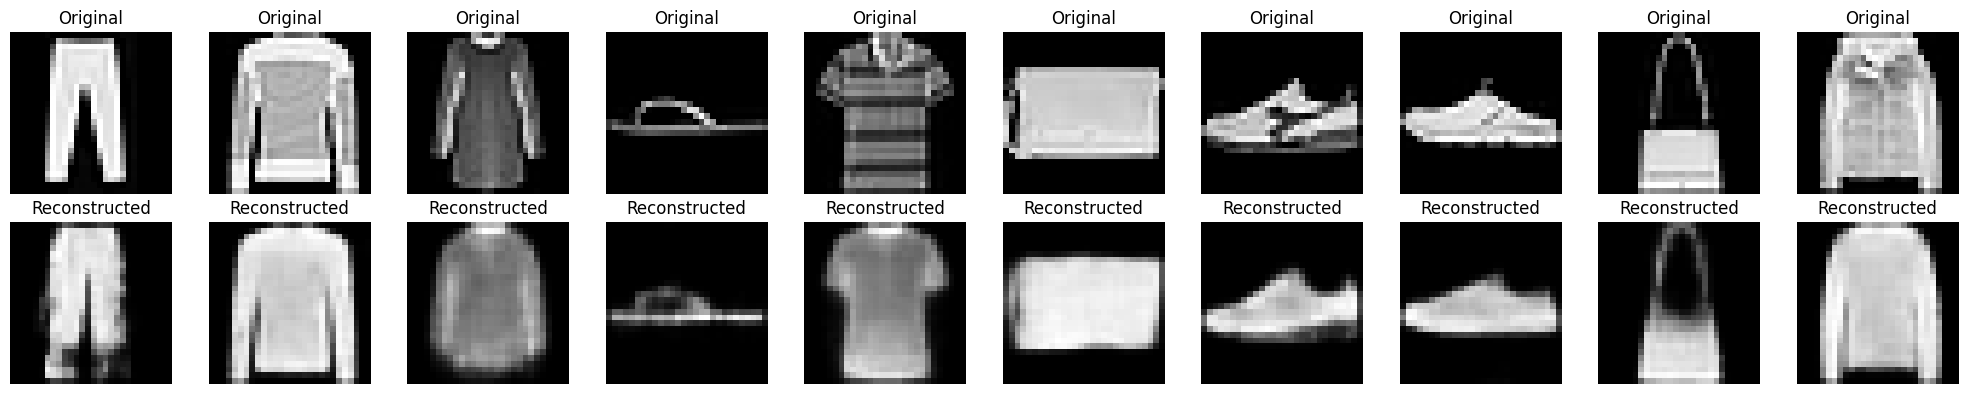

 74%|███████▍  | 23/31 [03:27<01:13,  9.25s/it]

Epoch: 23 | Training Loss: 240.38112
Epoch: 23 | Validation Loss: 239.69045


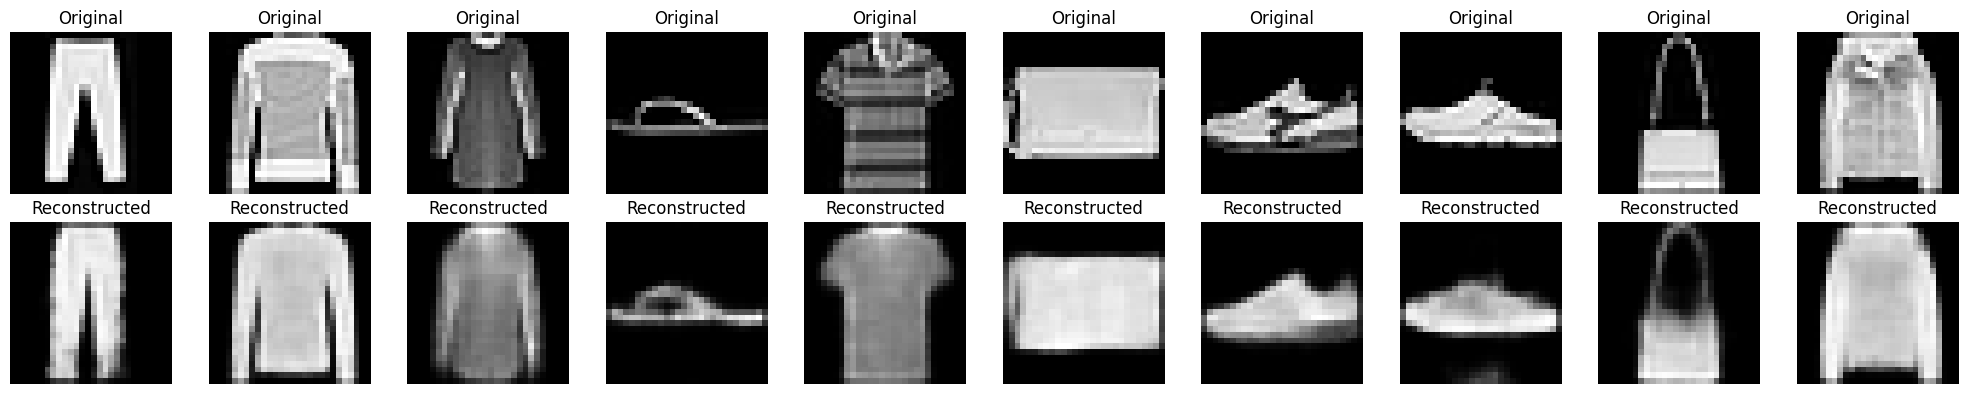

 77%|███████▋  | 24/31 [03:36<01:04,  9.26s/it]

Epoch: 24 | Training Loss: 240.23824
Epoch: 24 | Validation Loss: 239.76669


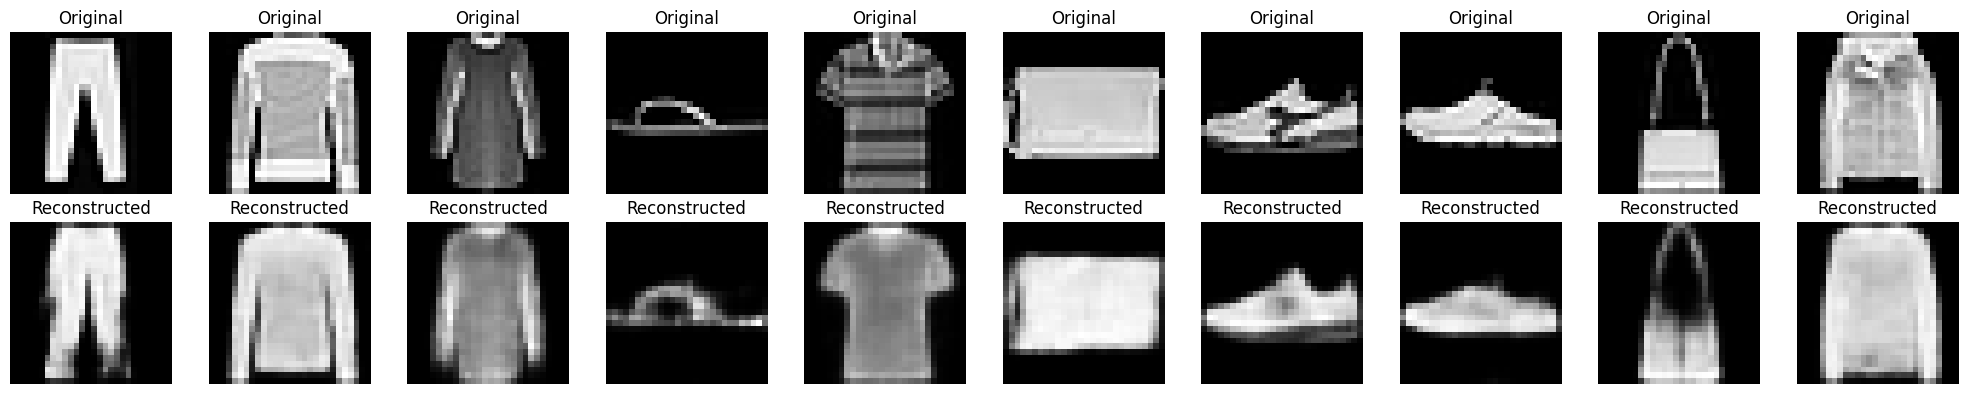

 81%|████████  | 25/31 [03:45<00:55,  9.26s/it]

Epoch: 25 | Training Loss: 240.15307
Epoch: 25 | Validation Loss: 239.51647


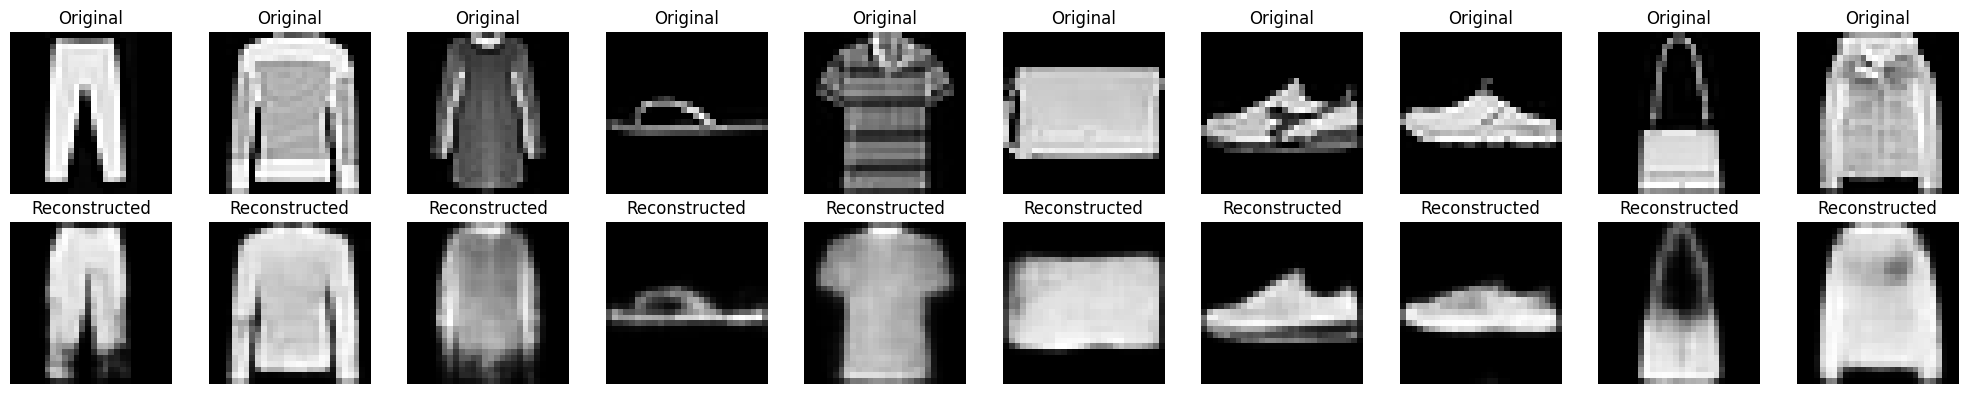

 84%|████████▍ | 26/31 [03:55<00:46,  9.26s/it]

Epoch: 26 | Training Loss: 240.08362
Epoch: 26 | Validation Loss: 239.60198


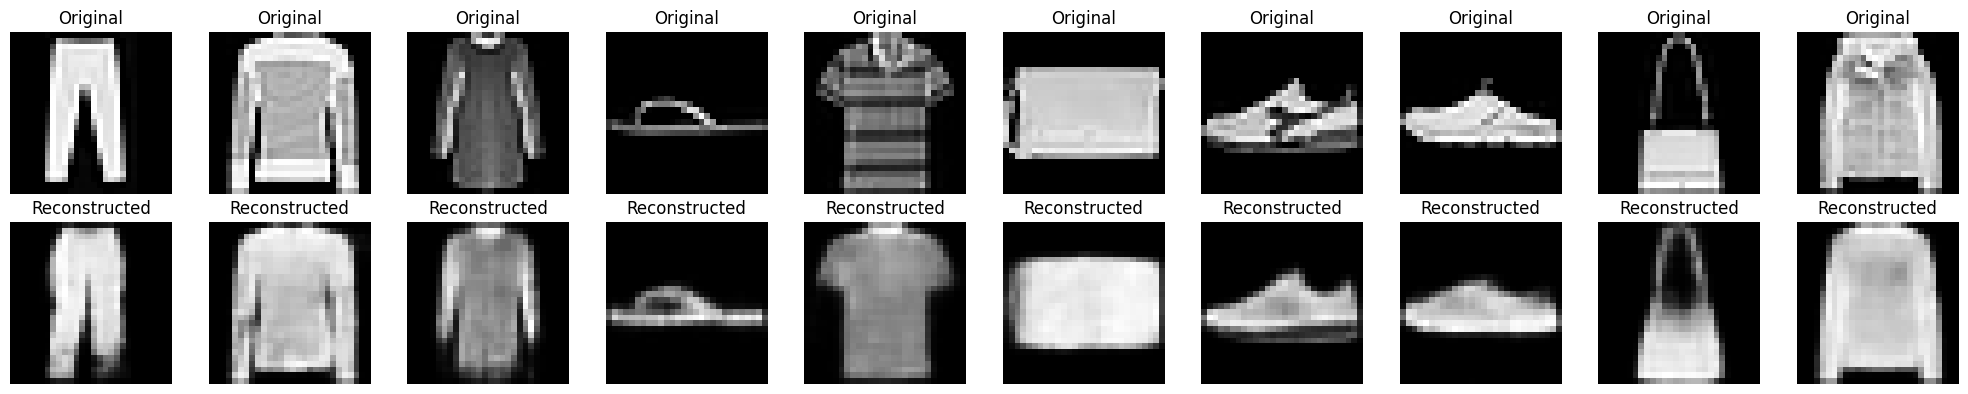

 87%|████████▋ | 27/31 [04:03<00:36,  9.08s/it]

Epoch: 27 | Training Loss: 239.92425
Epoch: 27 | Validation Loss: 239.29945


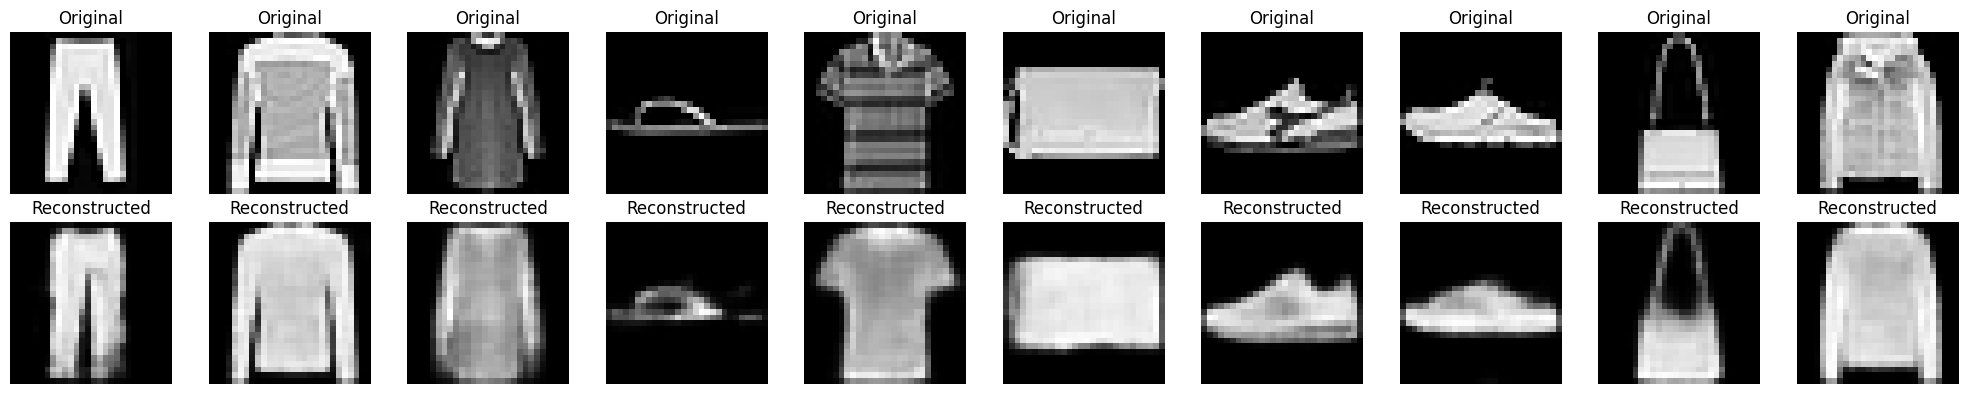

 90%|█████████ | 28/31 [04:13<00:27,  9.32s/it]

Epoch: 28 | Training Loss: 239.88312
Epoch: 28 | Validation Loss: 239.13682


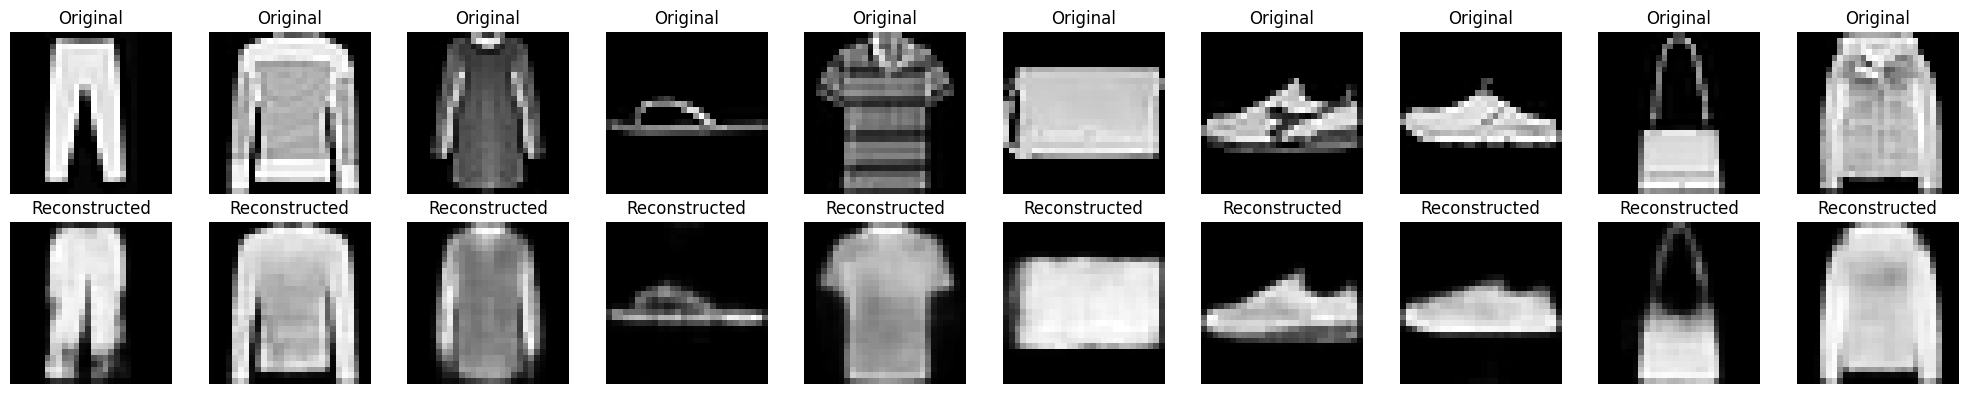

 94%|█████████▎| 29/31 [04:23<00:18,  9.40s/it]

Epoch: 29 | Training Loss: 239.75675
Epoch: 29 | Validation Loss: 239.28214


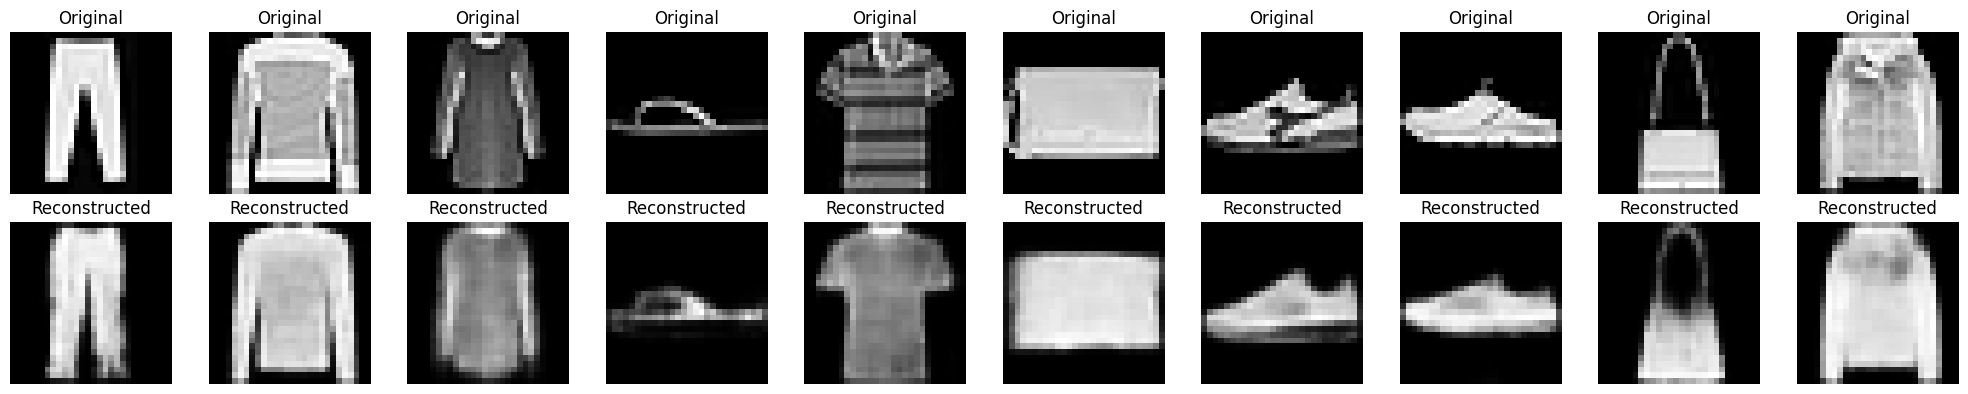

 97%|█████████▋| 30/31 [04:35<00:10, 10.35s/it]

Epoch: 30 | Training Loss: 239.69636
Epoch: 30 | Validation Loss: 239.19565


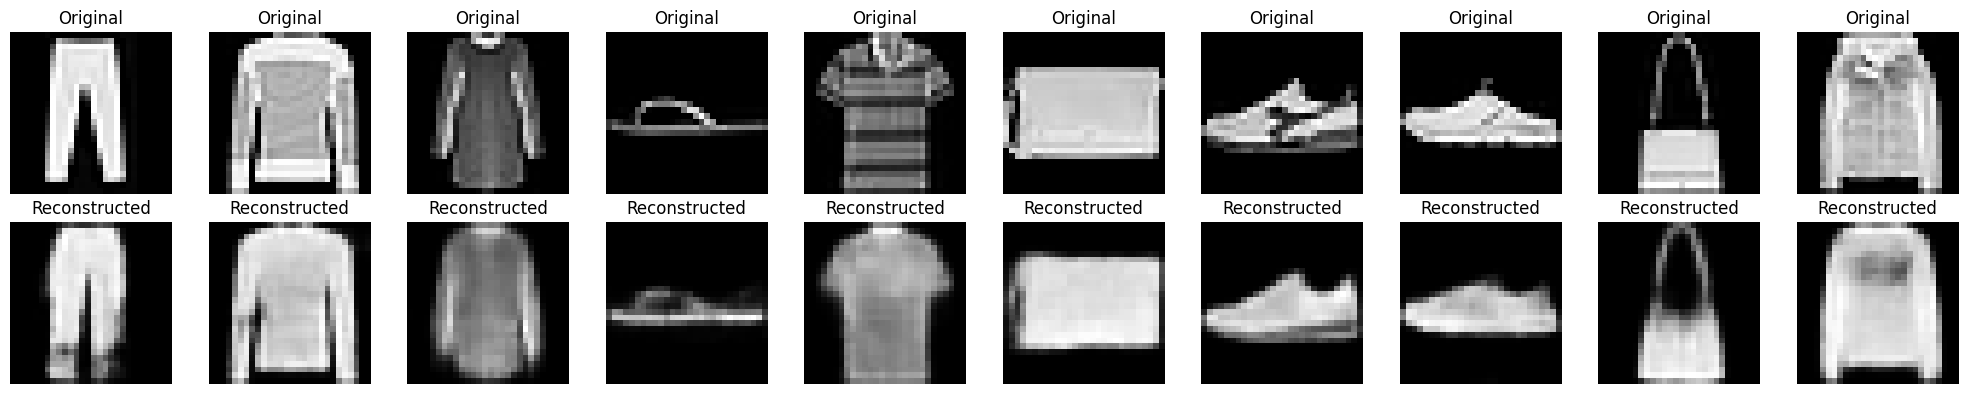

100%|██████████| 31/31 [04:45<00:00,  9.20s/it]


In [126]:
train_losses, val_losses, latent_params = train(train_dl, valid_dl, model, optimizer, epochs, device)

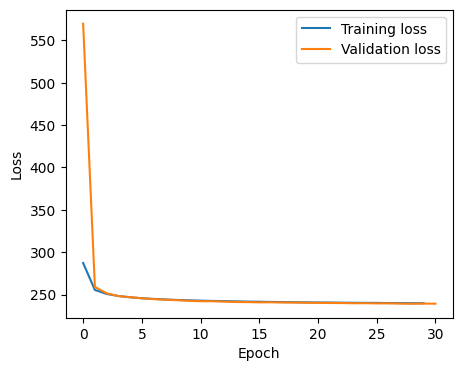

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

ax.plot(train_losses, label="Training loss")
ax.plot(val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

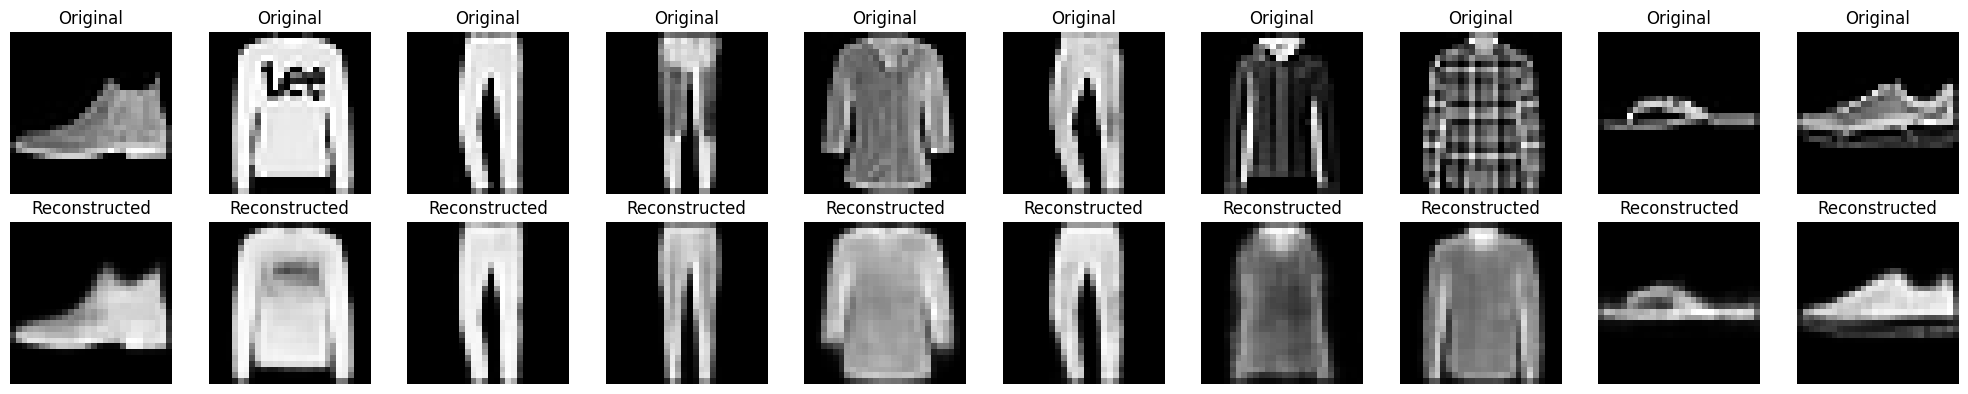

In [128]:
test_images, _ = next(iter(test_dl))
X_test_hat, _, _ = model(test_images.to(device))
display_images(test_images, X_test_hat)